---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [144]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

### Loading the Four Data Files

In [145]:
# Load each .csv into a dataframe
df_sessions = pd.read_csv("data/sessions.csv")
df_streamers = pd.read_csv("data/streamers.csv")
df_streams = pd.read_csv("data/streams.csv")
df_viewers = pd.read_csv("data/viewers.csv")

Each .csv file is loaded into its own DataFrame.

### sessions.csv

*Columns*

- *session_id*: **Numerical**
    - the id of the session a viewer watches a stream (the id starts with SES) (string)
- *viewer_id*: **Numerical**
    - the id of the viewer (the id starts with VWR) (string)
- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *stream_id*: **Numerical**
    - the id of the stream (the id starts with SM) (string)
- *started_at*: **Numerical**
    - the date and time the viewer started watching (year-month-date hour:min:sec format) (string)
- *ended_at*: **Numerical**
    - the date and time the viewer stopped watching (year-month-date hour:min:sec format) (string)
- *duration_mins*: **Numerical**
    - how long and sessions lastes in minutes (integer)
- *chat_messanges_sent*: **Numerical**
    - number of chat messages sent during the session (integer)
- *bits_cheered*: **Numerical**
    - number of bits cheered during the session (integer)
- *followed_during*: **Categorical**
    - did the viewer follow the streamer during the session (boolean)
- *subscribed_during*: **Categorical**
    - did the viewer subscribe to the streamer during the session (boolean)

In [146]:
df_sessions.head()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Shape of the Data

Text(0.5, 1.0, 'number of sessions vs. duration_mins')

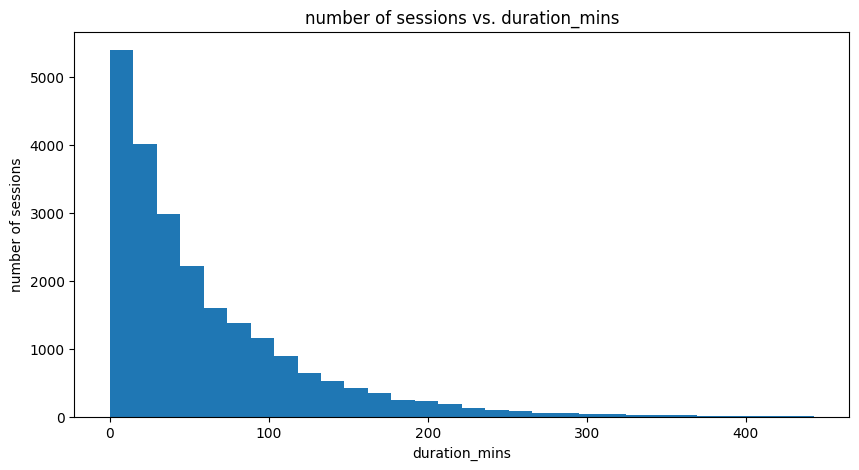

In [147]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["duration_mins"], bins=30)
plt.xlabel("duration_mins")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. duration_mins")

Most viewers tend to watch a stream for a few minutes, and as the duration_mins increases, the number of sessions decreases significantly.

Text(0.5, 1.0, 'number of sessions vs. chat_messages_sent')

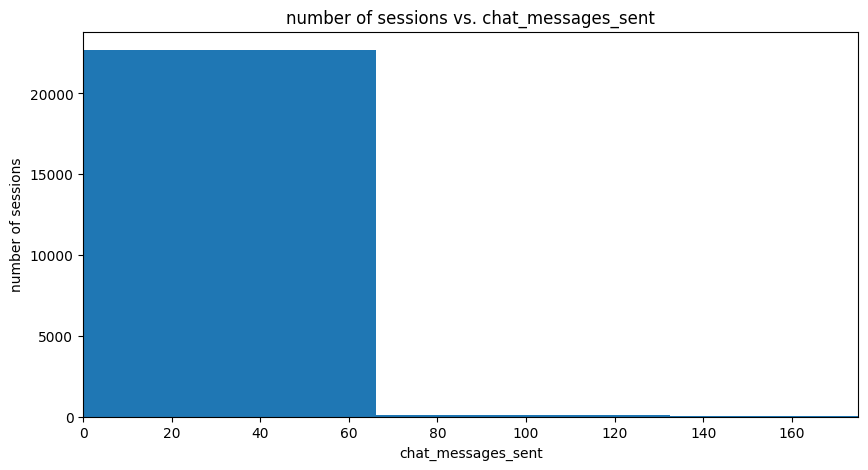

In [148]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["chat_messages_sent"], bins=30)
plt.xlim(0, 175)
plt.xlabel("chat_messages_sent")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. chat_messages_sent")

Most sessions have the number of chat messages that are less than 100. I think this means that viewers do not chat much during sessions. I excluded the data with the most amount of messages sent to see where most of the data is on the x axis. The most amount of chat messages sent is 1987 messages.

Text(0.5, 1.0, 'number of sessions vs. bits_cheered')

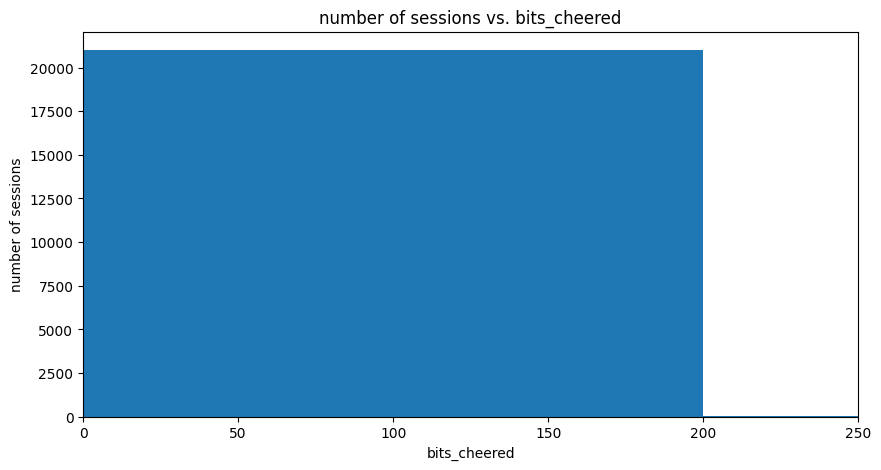

In [149]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["bits_cheered"], bins=50)
plt.xlim(0, 250)
plt.xlabel("bits_cheered")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. bits_cheered")

This plot of number of sessions vs. bits_cheered has a different shape as the previous plot for number of messages sent. The number of session is the same from 0 bits to 200 bits cheered. The plot is a measure of participation. I excluded the outliers same as in the previous plot. The most amount of bits cheered is over 20000.

#### Value Ranges

In [150]:
print(
    "Value Range of duration_mins: " +
    str(df_sessions["duration_mins"].min()) +
    " to "  + str(df_sessions["duration_mins"].max())
)

print(
    "Value Range of chat_messages_sent: " +
    str(df_sessions["chat_messages_sent"].min()) +
    " to "  + str(df_sessions["chat_messages_sent"].max())
)

print(
    "Value Range of bits_cheered: " +
    str(df_sessions["bits_cheered"].min()) +
    " to "  + str(df_sessions["bits_cheered"].max())
)

Value Range of duration_mins: 0 to 443
Value Range of chat_messages_sent: 0 to 1987
Value Range of bits_cheered: 0 to 10000


These show the range of values for the columns duration_mins, chat_messages_sent, and bits_cheered.

#### Possible Categories

In [151]:
print("Possible Categories of followed_during: " + str(df_sessions["followed_during"].unique()))
print("Possible Categories of subcribed_during: " + str(df_sessions["subscribed_during"].unique()))

Possible Categories of followed_during: [False  True]
Possible Categories of subcribed_during: [False  True]


Both columns here have boolean values and are therfore categories.

### streamers.csv

*Columns*

- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *streamer_name*: **Unstructured**
    - the name of the streamer (string)
- *category*: **Categorical**
    - the type of streams the streamer does (string)
- *language*: **Categorical**
    - the language used during the streams (string)
- *partner_status*: **Categorical**
    - does the streamer have a partner (boolean)
- *total_followers*: **Numerical**
    - the total amount of followers the streamer has (integer)
- *avg_concurrent_viewers*: **Numerical**
    - average concurrent viewers per stream (integer)

In [152]:
df_streamers.head()

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Shape of the Data

Text(0.5, 1.0, 'number of streamers vs. total_followers')

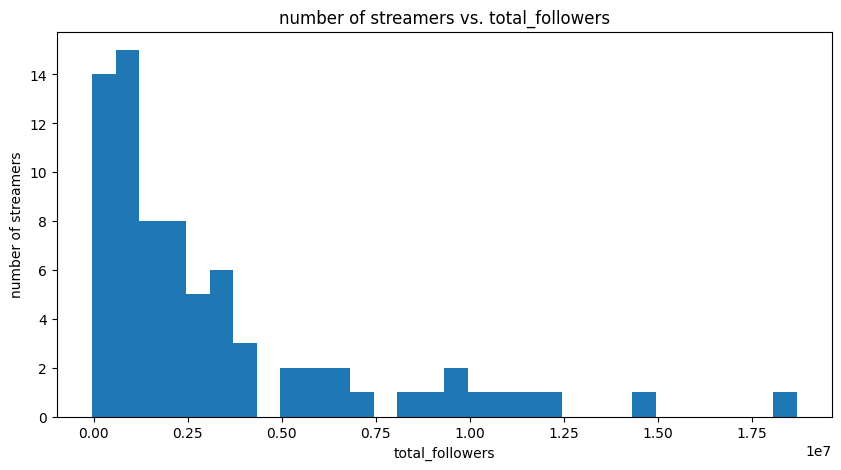

In [153]:
plt.figure(figsize=(10, 5))
plt.hist(df_streamers["total_followers"], bins=30)
plt.xlabel("total_followers")
plt.ylabel("number of streamers")
plt.title("number of streamers vs. total_followers")

This plot has a similar shape to the number of sessions vs. duration_mins plot, but is not continuous. There are a lot of streamers with low follower counts and a few streams with high follower counts.

Text(0.5, 1.0, 'number of streamers vs. avg_concurrent_viewers')

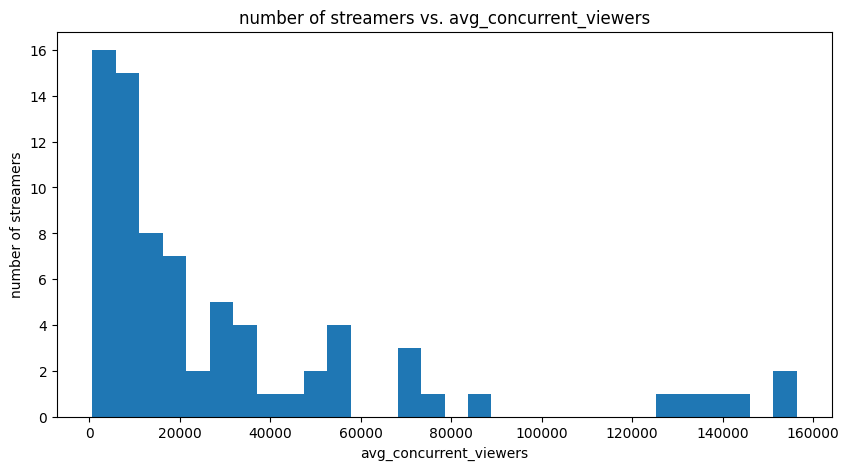

In [154]:
plt.figure(figsize=(10, 5))
plt.hist(df_streamers["avg_concurrent_viewers"], bins=30)
plt.xlabel("avg_concurrent_viewers")
plt.ylabel("number of streamers")
plt.title("number of streamers vs. avg_concurrent_viewers")

This plot has a similar shape to the previous plot and is not continuous. There is a slight increase in average concurrent viewers to the right most of the plot. Most streamers do not have a lot of  concurrent viewers compared to the right most values.

#### Value Ranges

In [155]:
print(
    "Value Range of total_followers: " +
    str(df_streamers["total_followers"].min()) +
    " to "  + str(df_streamers["total_followers"].max())
)

print(
    "Value Range of avg_concurrent_viewers: " +
    str(df_streamers["avg_concurrent_viewers"].min()) +
    " to "  + str(df_streamers["avg_concurrent_viewers"].max())
)

Value Range of total_followers: -46964 to 18700000
Value Range of avg_concurrent_viewers: 634 to 156401


The minimum value for total_followers does not make sense becuase there cannot be a negative amount of followers. avg_concurrent_viewers' value range makes sense.

#### Possible Categories

In [156]:
print("Possible Categories of category: " + str(df_streamers["category"].unique()))
print("Possible Categories of language: " + str(df_streamers["language"].unique()))
print("Possible Categories of partner_status: " + str(df_streamers["partner_status"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 6, dtype: str
Possible Categories of language: <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str
Possible Categories of partner_status: [ True False]


The categories for the language column has a NaN value which needs data cleaning.

### streams.csv

*Columns*

- *stream_id*: **Numerical**
    - the id of the stream (the id starts with SM) (string)
- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *started_at*: **Numerical**
    - the date and time the stream started (year-month-date hour:min:sec format) (string)
- *ended_at*: **Numerical**
    - the date and time the stream ended (year-month-date hour:min:sec format) (string)
- *stream_duration_hrs*: **Numerical**
    - how long the stream lasted in hours (float)
- *category*: **Categorical**
    - the type of stream (string)
- *peak_viewers*: **Numerical**
    - the highest viewer count during the stream (float)
- *title_has_hype_word*: **Categorical**
    - if the title of the stream has the word hype (boolean)
- *was_raid*: **Categorical**
    - of the stream was raided (boolean)

In [157]:
df_streams.head()

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Shape of the Data

Text(0.5, 1.0, 'number of streams vs. stream_duration_hrs')

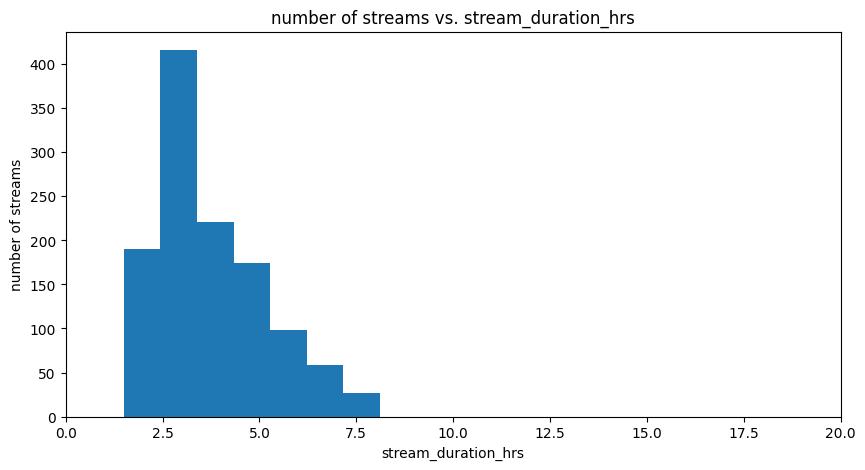

In [158]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["stream_duration_hrs"], bins=100)
plt.xlim(0, 20)
plt.xlabel("stream_duration_hrs")
plt.ylabel("number of streams")
plt.title("number of streams vs. stream_duration_hrs")

There is a peak in the shape of the data. The most amount a streams tend to last a little over 2.5 hours. I excluded the outliers which had high values in stream_duration_hrs so I could view the majority of the data in more detail.

Text(0.5, 1.0, 'number of streams vs. peak_viewers')

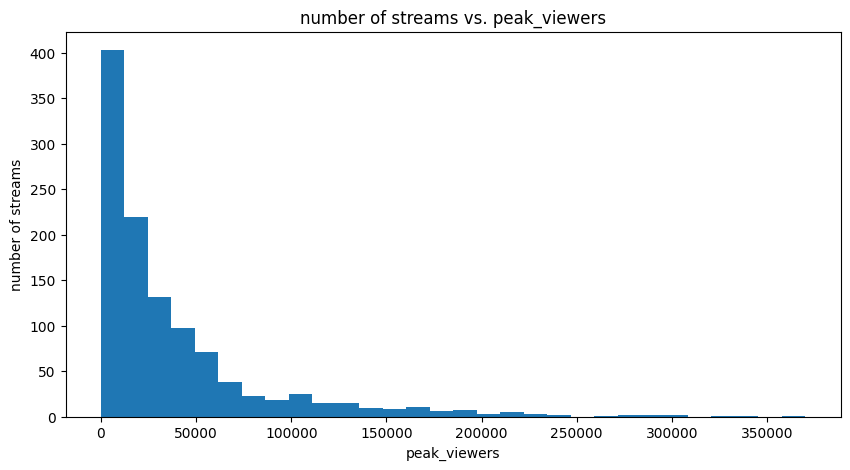

In [159]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["peak_viewers"], bins=30)
plt.xlabel("peak_viewers")
plt.ylabel("number of streams")
plt.title("number of streams vs. peak_viewers")

The shape of this plot decrease signicicantly as peak viewership increases.

#### Value Ranges

In [160]:
print(
    "Value Range of stream_duration_hrs: " +
    str(df_streams["stream_duration_hrs"].min()) +
    " to "  + str(df_streams["stream_duration_hrs"].max())
)

print(
    "Value Range of peak_viewers: " +
    str(df_streams["peak_viewers"].min()) +
    " to "  + str(df_streams["peak_viewers"].max())
)

Value Range of stream_duration_hrs: 1.5 to 96.0
Value Range of peak_viewers: -50.0 to 370165.0


stream_duration_hrs' data type of float is appropriate because there can be amounts that are fractions of hours. For peak_viewers, there are partial amounts of peak viewers and negative values that need to be cleaned.

#### Possible Categories

In [161]:
print("Possible Categories of category: " + str(df_streams["category"].unique()))
print("Possible Categories of title_has_hype_word: " + str(df_streams["title_has_hype_word"].unique()))
print("Possible Categories of was_raid: " + str(df_streams["was_raid"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str
Possible Categories of title_has_hype_word: [False  True]
Possible Categories of was_raid: [ True False]


category has a NaN category which need data cleaning. was_raid's categories are reversed compared to title_has_hype_word. was_raid's True value has a space in front of it. was_raid needs data cleaning.

### viewers.csv

*Columns*

- *viewer_id*: **Numerical**
    - the id of the viewer (the id starts with VWR) (string)
- *age_group*: **Categorical**
    - the age range of the viewer (string)
- *country*: **Categorical**
    - the country the viewer are located in (string)
- *account_age_days*: **Numerical**
    - how on the viewer account is in days (int)
- *subscription_tier*: **Categorical**
    - the subscription tier of the viewer (string)
- *preferred_category*: **Categorical**
    - the type of stream the viewer prefers (string)

In [162]:
df_viewers.head()

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Combining Categories

In [163]:
df_viewers["age_group_cleaned"] = df_viewers["age_group"]

mapping = {
    "18–24": "18-24",
    "18 to 24": "18-24",
    "25–34": "25-34",
    "25 to 34": "25-34",
    "35–44": "35-44",
    "35 to 44": "35-44",
}

df_viewers["age_group_cleaned"] = df_viewers["age_group_cleaned"].replace(mapping)

In [164]:
df_viewers["subscription_tier_cleaned"] = df_viewers["subscription_tier"]

mapping = {
    "TIER1": "tier1",
}

df_viewers["subscription_tier_cleaned"] = df_viewers["subscription_tier_cleaned"].replace(mapping)

There were several same type categories that were written differently. I combined them into a new column.

#### Shape of the Data

Text(0.5, 1.0, 'number of viewers vs. account_age_days')

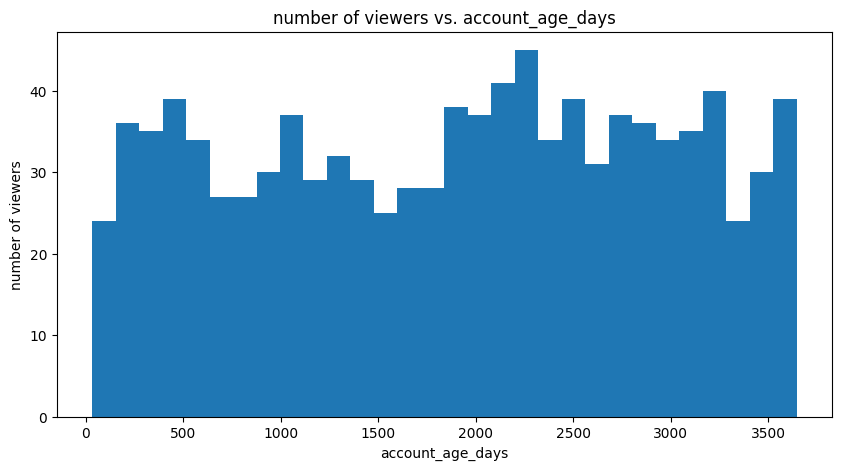

In [165]:
plt.figure(figsize=(10, 5))
plt.hist(df_viewers["account_age_days"], bins=30)
plt.xlabel("account_age_days")
plt.ylabel("number of viewers")
plt.title("number of viewers vs. account_age_days")

There is no shape in the data. There are a diverse and spread out number of viewers who have new and old accounts.

Text(0.5, 1.0, 'number of viewers vs. age_group_cleaned')

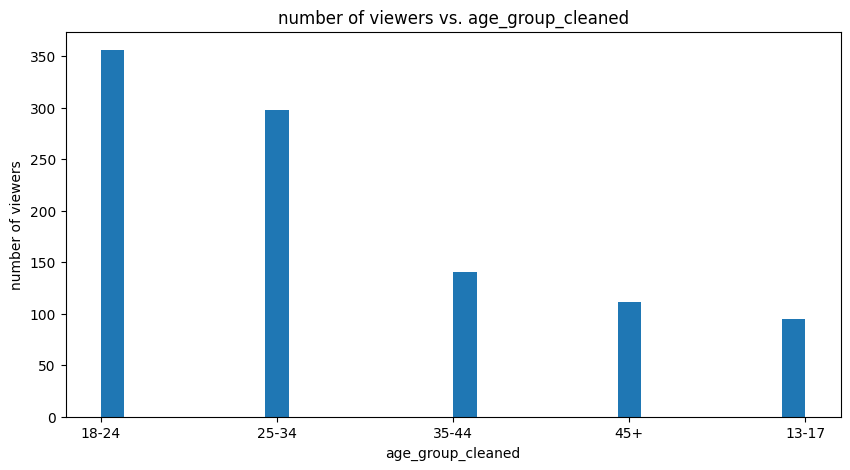

In [166]:
plt.figure(figsize=(10, 5))
plt.hist(df_viewers["age_group_cleaned"], bins=30)
plt.xlabel("age_group_cleaned")
plt.ylabel("number of viewers")
plt.title("number of viewers vs. age_group_cleaned")

Most of the viewers are ages 18-24 and 25-34.

#### Value Ranges

In [167]:
print(
    "Value Range of account_age_days: " +
    str(df_viewers["account_age_days"].min()) +
    " to "  + str(df_viewers["account_age_days"].max())
)

Value Range of account_age_days: 33 to 3645


The account_age_days value range makes sense.

#### Possible Categories

In [168]:
print("Possible Categories of age_group: " + str(df_viewers["age_group"].unique()))
print("Possible Categories of age_group_cleaned: " + str(df_viewers["age_group_cleaned"].unique()))
print("Possible Categories of country: " + str(df_viewers["country"].unique()))
print("Possible Categories of subscription_tier: " + str(df_viewers["subscription_tier"].unique()))
print("Possible Categories of subscription_tier_cleaned: " + str(df_viewers["subscription_tier_cleaned"].unique()))
print("Possible Categories of preferred_category: " + str(df_viewers["preferred_category"].unique()))

Possible Categories of age_group: <StringArray>
[   '18-24',    '25-34',    '35-44',      '45+',    '13-17',    '18–24',
    '25–34', '35 to 44', '18 to 24', '25 to 34',    '35–44']
Length: 11, dtype: str
Possible Categories of age_group_cleaned: <StringArray>
['18-24', '25-34', '35-44', '45+', '13-17']
Length: 5, dtype: str
Possible Categories of country: <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str
Possible Categories of subscription_tier: <StringArray>
[      'free',      'tier1',      'tier2',      'tier3', 'free trial',
    'premium',       'none',      'tier4',      'TIER1']
Length: 9, dtype: str
Possible Categories of subscription_tier_cleaned: <StringArray>
['free', 'tier1', 'tier2', 'tier3', 'free trial', 'premium', 'none', 'tier4']
Length: 8, dtype: str
Possible Categories of preferred_category:

For age_group, there are categories of 18-24, 25-34, and 35-44 written is in different ways and needs to be cleaned. subscription_tier also needs to be clean because of two ways tier1 is written.

### Task 1 Summary Report

The relationships of each .csv files to the other ones
- sessions point to viewers, streamer, and streams
- streamers do not point to anything
- streams point to streamers
- viewers do not point to anything

There is data cleanup to be done
- NaN values need to be removed
- there are some negative values that do not make sense

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


#### Checking id Columns for NaN Values

In [169]:
dfs = {
    "df_sessions": df_sessions,
    "df_streamers": df_streamers,
    "df_streams": df_streams,
    "df_viewers": df_viewers,
}

id_columns = ["session_id", "viewer_id", "streamer_id", "stream_id"]

for df_name, df in dfs.items():
    print(f"--- {df_name} ---")

    available_cols = [col for col in id_columns if col in df.columns]

    if not available_cols:
        print("None of the columns exist in this DataFrame.")
        continue

    null_counts = df[available_cols].isna().sum()

    print(null_counts)

--- df_sessions ---
session_id      0
viewer_id       0
streamer_id    60
stream_id       0
dtype: int64
--- df_streamers ---
streamer_id    0
dtype: int64
--- df_streams ---
streamer_id    0
stream_id      0
dtype: int64
--- df_viewers ---
viewer_id    0
dtype: int64


There are 60 null values in streamer_id column. These rows containing these null values will be deleted from the DataFrame.

### sessions.csv

In [170]:
df_sessions = df_sessions.dropna(subset=["streamer_id"])
print("Number of streamer_id NaN values: " + str(df_sessions["streamer_id"].isna().sum()))


Number of streamer_id NaN values: 0


There are no NaN values in the column streamer_id.

In [171]:
df_sessions = df_sessions[df_sessions["duration_mins"] >= 0]

df_sessions["started_at"] = pd.to_datetime(df_sessions["started_at"])
df_sessions["ended_at"] = pd.to_datetime(df_sessions["ended_at"])

calculated_mins = (df_sessions["ended_at"] - df_sessions["started_at"]).dt.total_seconds() / 60
is_valid_duration = (calculated_mins > 0) & (calculated_mins == df_sessions["duration_mins"])
df_sessions = df_sessions[is_valid_duration].reset_index(drop=True)

check_mins = (df_sessions["ended_at"] - df_sessions["started_at"]).dt.total_seconds() / 60
incorrect_rows = df_sessions[(check_mins <= 0) | (check_mins != df_sessions["duration_mins"])]

if incorrect_rows.empty:
    print("0 incorrect values found.")
else:
    print(f"Found {len(incorrect_rows)} incorrect rows.")
    print(incorrect_rows)

0 incorrect values found.


Any rows with duration_mins values that were negative, the difference between started_at and ended_at were negative, and if this difference was not the same as duration_mins were deleted.

### streamers.csv

In [172]:
df_streamers["total_followers_cleaned"] = df_streamers["total_followers"].map(lambda i: 0 if i < 0 or pd.isna(i) else i)
print(
    "Value Range of total_followers: " +
    str(df_streamers["total_followers"].min()) +
    " to "  + str(df_streamers["total_followers"].max())
)

print(
    "Value Range of total_followers_cleaned: " +
    str(df_streamers["total_followers_cleaned"].min()) +
    " to "  + str(df_streamers["total_followers_cleaned"].max())
)

Value Range of total_followers: -46964 to 18700000
Value Range of total_followers_cleaned: 0 to 18700000


I have converted all the negative and NaN values of total_followers to 0 because a streamer cannot have negative or NaN followers.

In [173]:
df_streamers["language_cleaned"] = df_streamers["language"].fillna("other")
print("Possible Categories of language: " + str(df_streamers["language"].unique()))
print("Possible Categories of language_cleaned: " + str(df_streamers["language_cleaned"].unique()))

Possible Categories of language: <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str
Possible Categories of language_cleaned: <StringArray>
['English', 'Spanish', 'other', 'Korean', 'Portuguese']
Length: 5, dtype: str


Converting NaN values to other for the language_cleaned column makes more sense because the streamer with NaN language values could be speaking a different language that is not listed in this column.

### streams.csv

In [174]:
df_streams["peak_viewers_cleaned"] = df_streams["peak_viewers"].map(lambda i: 0 if i < 0 or pd.isna(i) else i)
print(
    "Value Range of peak_viewers: " +
    str(df_streams["peak_viewers"].min()) +
    " to "  + str(df_streams["peak_viewers"].max())
)

print(
    "Value Range of peak_viewers_cleaned: " +
    str(df_streams["peak_viewers_cleaned"].min()) +
    " to "  + str(df_streams["peak_viewers_cleaned"].max())
)

Value Range of peak_viewers: -50.0 to 370165.0
Value Range of peak_viewers_cleaned: 0.0 to 370165.0


I have converted all the negative and NaN values of peak_viewers to 0 because a stream cannot have negative or NaN peak views.

In [175]:
df_streams["category_cleaned"] = df_streams["category"].fillna("other")
print("Possible Categories of category: " + str(df_streams["category"].unique()))
print("Possible Categories of category_cleaned: " + str(df_streams["category_cleaned"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str
Possible Categories of category_cleaned: <StringArray>
['Just Chatting', 'other', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str


Converting NaN values to other for the category_cleaned column makes more sense because streams with NaN language values could be other categories that are not listed in this column.

In [176]:
df_streams = df_streams[df_streams["stream_duration_hrs"] >= 0]

df_streams["started_at"] = pd.to_datetime(df_streams["started_at"])
df_streams["ended_at"] = pd.to_datetime(df_streams["ended_at"])

calculated_hrs = (df_streams["ended_at"] - df_streams["started_at"]).dt.total_seconds() / 3600
is_valid_duration = (calculated_hrs > 0) & (calculated_hrs == df_streams["stream_duration_hrs"])
df_streams = df_streams[is_valid_duration].reset_index(drop=True)

check_hrs = (df_streams["ended_at"] - df_streams["started_at"]).dt.total_seconds() / 3600
incorrect_rows = df_streams[(check_hrs <= 0) | (check_hrs != df_streams["stream_duration_hrs"])]

if incorrect_rows.empty:
    print("0 incorrect values found.")
else:
    print(f"Found {len(incorrect_rows)} incorrect rows.")
    print(incorrect_rows)

0 incorrect values found.


Any rows with stream_duration_hrs values that were negative, the difference between started_at and ended_at were negative, and if this difference was not the same as stream_duration_hrs were deleted.

### viewers.csv

In [177]:
df_viewers["country_cleaned"] = df_viewers["country"].fillna("other")
print("Possible Categories of country: " + str(df_viewers["country"].unique()))
print("Possible Categories of country_cleaned: " + str(df_viewers["country_cleaned"].unique()))

Possible Categories of country: <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str
Possible Categories of country_cleaned: <StringArray>
[   'AR',    'CA',    'US', 'other',    'DE',    'ES',    'FR',    'GB',
    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',    'JP',
    'IN',    'KR',    'AU',    'TR']
Length: 20, dtype: str


Converting NaN values to other for the country_cleaned column makes more sense because the viewers with NaN language values could be in a differnt country that is not listed in this column.

### Heuristics

- streamer ids that are NaN
    - this is an error because the streamer needs an id to be identified
- duration of sessions and streams were negative
    - this is an error because it is miscalculated
- the difference between start and end times of sessions and streams were negative
    - this is an error because it is miscalculated
    - the difference was not the same as duration_mins
        - this is an error because it is miscalculated
- a streamer having negative total followers
    - this is an artifact because it does not make sense to have a quantity of something that is negative
- a streamer having NaN for a language
    - maybe be an arifact for the cases where the language is unknown
- a stream that has negative peak viewers
    - this is an artifact becaise it does not make sense to have a quanityt of somethings that is negative
- a stream that has NaN for a category
    - this is an arfitact because the stream can be another category not listed in the data
- viewers that have NaN country values
    - this is an artifact because the viewers can be in a country that is not listed in the data

### Task 2 summary report

Throught the four csv files, certain rows needed to be modified or deleted
- some rows needed to be deleted beucase of NaNs and miscalutations
- certain negative values were changed to 0
- NaNs values in categorical columns were changed to "other"

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

### sessions.csv

In [178]:
print("duration_mins stats: \n" +
      "median " + str(df_sessions["duration_mins"].median()) + "\n" +
      str(df_sessions["duration_mins"].describe()),"\n"
)
print("chat_messages_sent stats: \n" +
      "median " + str(df_sessions["chat_messages_sent"].median()) + "\n" +
      str(df_sessions["chat_messages_sent"].describe()),"\n"
)
print("bits_cheered stats: \n" +
      "median " + str(df_sessions["bits_cheered"].median()) + "\n" +
      str(df_sessions["bits_cheered"].describe()),"\n"
)

duration_mins stats: 
median 39.0
count    22644.000000
mean        59.255211
std         60.401259
min          2.000000
25%         16.000000
50%         39.000000
75%         83.000000
max        443.000000
Name: duration_mins, dtype: float64 

chat_messages_sent stats: 
median 1.0
count    22644.000000
mean         4.886725
std         10.025623
min          0.000000
25%          0.000000
50%          1.000000
75%          5.000000
max        220.000000
Name: chat_messages_sent, dtype: float64 

bits_cheered stats: 
median 0.0
count    22644.000000
mean       397.445548
std       1570.153385
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      10000.000000
Name: bits_cheered, dtype: float64 



Text(0.5, 1.0, 'duration_mins Boxplot')

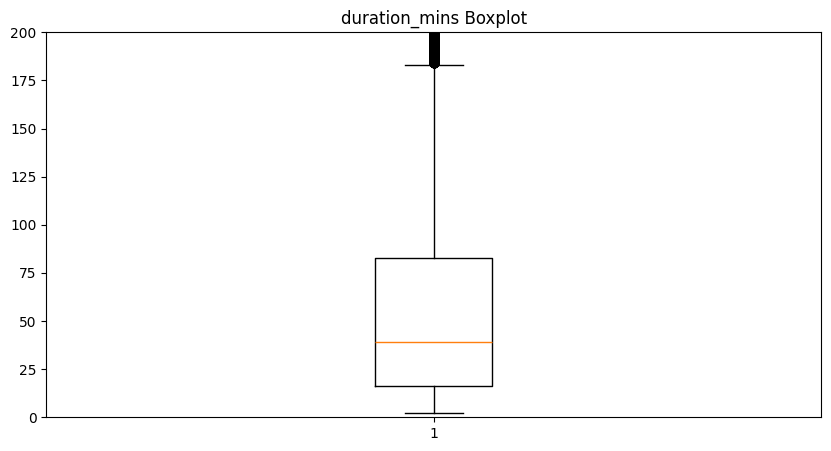

In [179]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["duration_mins"])
plt.ylim(0, 200)
plt.title("duration_mins Boxplot")

More of the data is skewed towards the bottom of the box plot. There are a lot of outliers towards the top and I zoomed in on the boxplot.

Text(0.5, 1.0, 'chat_messages_sent Boxplot')

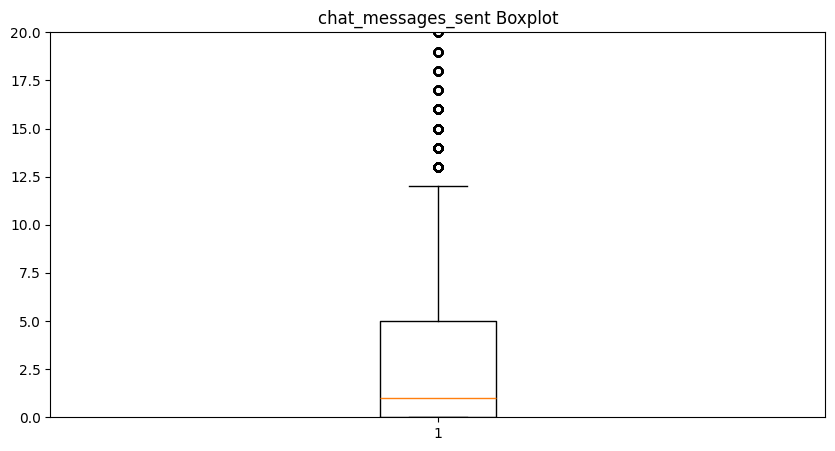

In [180]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["chat_messages_sent"])
plt.ylim(0, 20)
plt.title("chat_messages_sent Boxplot")

The boxplot is more skewed towards 0 compared to the previous plot. Each point at the top is an outlier.

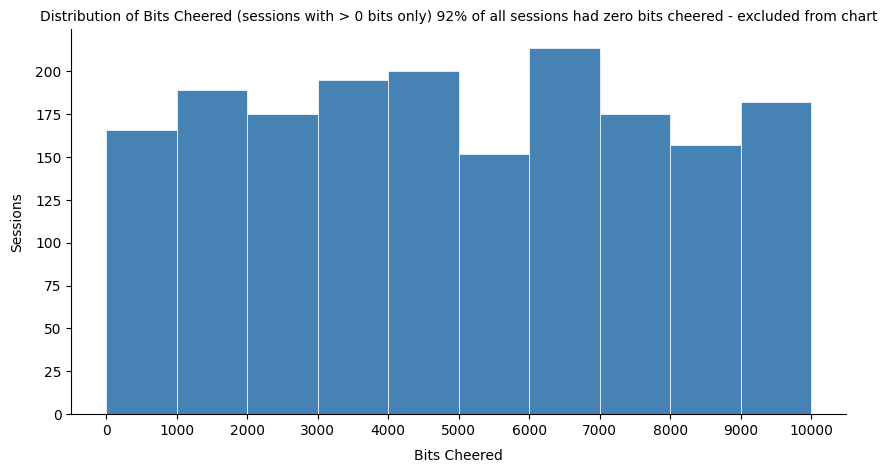

In [181]:
zero_pct = (df_sessions["bits_cheered"] == 0).mean() * 100
cheerers = df_sessions[df_sessions["bits_cheered"] > 0]["bits_cheered"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(cheerers, bins=10, range=(0, 10000), color="steelblue", edgecolor="white", linewidth=0.5)

ax.set_xlabel("Bits Cheered", labelpad=8)
ax.set_ylabel("Sessions", labelpad=8)

title = (
    "Distribution of Bits Cheered (sessions with > 0 bits only) "
    + str(round(zero_pct)) + "% of all sessions had zero bits cheered - excluded from chart"
)
ax.set_title(title, fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(range(0, 11000, 1000))

plt.show()

92% of sessions had no cheering activity (0 values). There is no shape in the data.

In [182]:
print(df_sessions["followed_during"].value_counts(), "\n")
print(df_sessions["subscribed_during"].value_counts())

followed_during
False    21488
True      1156
Name: count, dtype: int64 

subscribed_during
False    22206
True       438
Name: count, dtype: int64


Text(0.5, 1.0, 'subscribed_during pie chart')

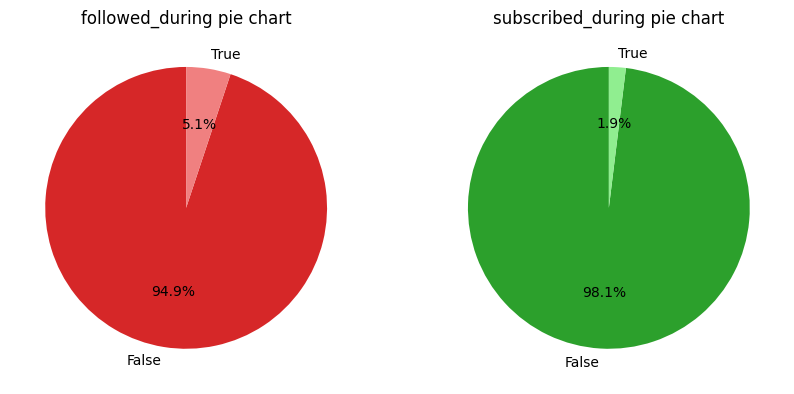

In [183]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

fd_counts = df_sessions["followed_during"].value_counts()
ax1.pie(
    fd_counts.values, 
    labels=fd_counts.index.astype(str), 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=["tab:red", "lightcoral"]
)
ax1.set_title("followed_during pie chart")

sd_counts = df_sessions["subscribed_during"].value_counts()
ax2.pie(
    sd_counts.values, 
    labels=sd_counts.index.astype(str), 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=["tab:green", "lightgreen"]
)
ax2.set_title("subscribed_during pie chart")

For both plots, most of the sessions do not have follows or subscriptions.

### streamers.csv

In [184]:
print("total_followers_cleaned stats: \n" +
      "median " + str(df_streamers["total_followers_cleaned"].median()) + "\n" +
      str(df_streamers["total_followers_cleaned"].describe()),"\n"
)
print("avg_concurrent_viewers stats: \n" +
      "median " + str(df_streamers["avg_concurrent_viewers"].median()) + "\n" +
      str(df_streamers["avg_concurrent_viewers"].describe()),"\n"
)

total_followers_cleaned stats: 
median 2000000.0
count    7.600000e+01
mean     3.303026e+06
std      3.791873e+06
min      0.000000e+00
25%      7.800000e+05
50%      2.000000e+06
75%      3.875000e+06
max      1.870000e+07
Name: total_followers_cleaned, dtype: float64 

avg_concurrent_viewers stats: 
median 14762.5
count        76.000000
mean      31227.986842
std       38307.223652
min         634.000000
25%        6633.250000
50%       14762.500000
75%       36840.750000
max      156401.000000
Name: avg_concurrent_viewers, dtype: float64 



Text(0.5, 1.0, 'total_followers_cleaned Boxplot')

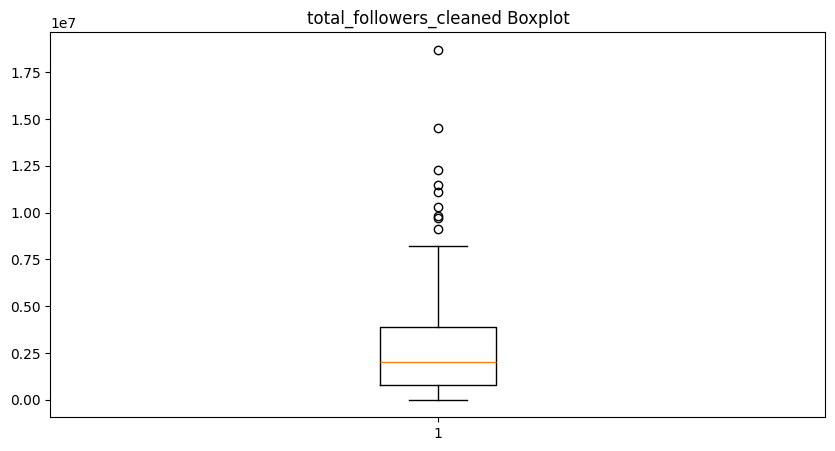

In [185]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streamers["total_followers_cleaned"])
plt.title("total_followers_cleaned Boxplot")

This boxplot of skewed to the bottom. Most streamers do not have a lot fo followers compared to the outliers.

Text(0.5, 1.0, 'avg_concurrent_viewers Boxplot')

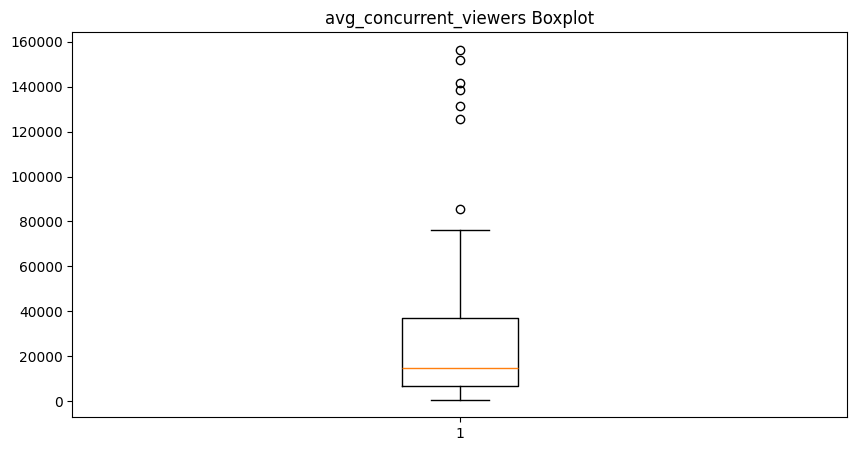

In [186]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streamers["avg_concurrent_viewers"])
plt.title("avg_concurrent_viewers Boxplot")

This boxplot is skewed towards the bottom and only have outliers at the top half of the plot.

In [187]:
print(df_streamers["category"].value_counts(), "\n")
print(df_streamers["language"].value_counts(), "\n")
print(df_streamers["partner_status"].value_counts())

category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9
Name: count, dtype: int64 

language
English       61
Spanish        5
Korean         1
Portuguese     1
Name: count, dtype: int64 

partner_status
True     66
False    10
Name: count, dtype: int64


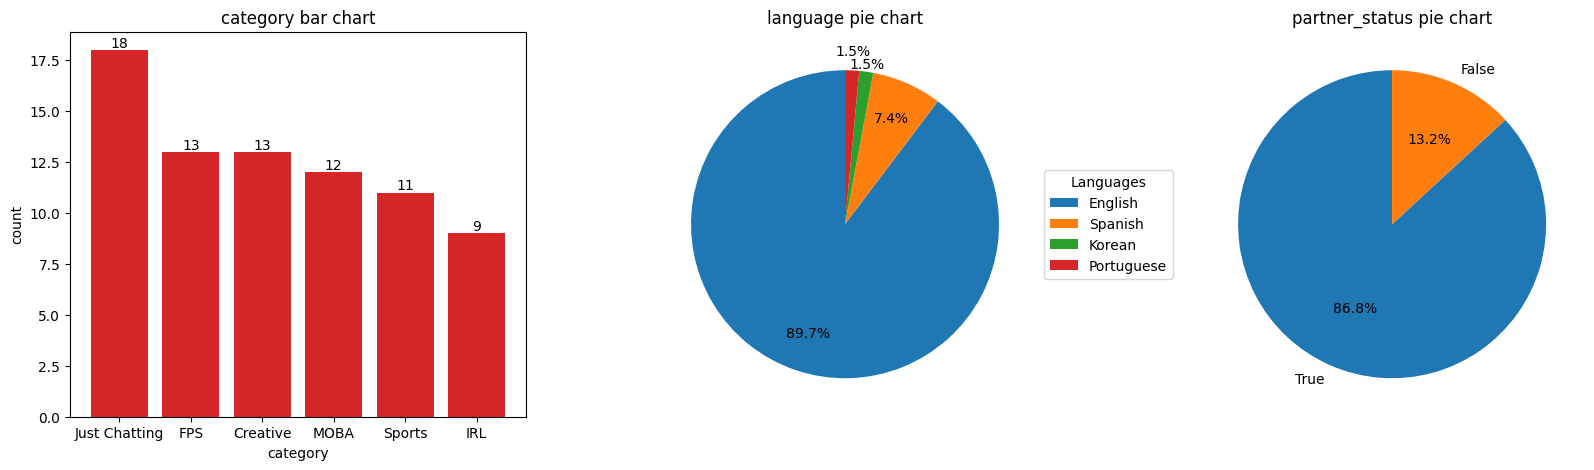

In [188]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

str_c_counts = df_streamers["category"].value_counts()
str_c_bars = ax1.bar(str_c_counts.index.astype(str), str_c_counts.values, color="tab:red")
ax1.bar_label(str_c_bars)
ax1.set_title("category bar chart")
ax1.set_xlabel("category")
ax1.set_ylabel("count")

l_counts = df_streamers["language"].value_counts()
wedges, texts, autotexts = ax2.pie(
    l_counts.values, 
    autopct='%1.1f%%', 
    startangle=90,
    pctdistance=0.75
)
plt.setp(autotexts, size=10)

for i, lang in enumerate(l_counts.index.astype(str)):
    if lang == 'Portuguese':
        x, y = autotexts[i].get_position()
        autotexts[i].set_position((x * 1.5, y * 1.5))
        
    elif lang == 'Korean':
        x, y = autotexts[i].get_position()
        autotexts[i].set_position((x * 1.4, y * 1.4))

ax2.legend(wedges, l_counts.index.astype(str), title="Languages", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax2.set_title("language pie chart")

ps_counts = df_streamers["partner_status"].value_counts()
ax3.pie(
    ps_counts.values, 
    labels=ps_counts.index.astype(str), 
    autopct='%1.1f%%', 
    startangle=90
)
ax3.set_title("partner_status pie chart")

plt.show()

Streamers that do streams about Just Chatting, speak English, and have a partner is the majority of the data.

### streams.csv

In [189]:
print("stream_duration_hrs stats: \n" +
      "median " + str(df_streams["stream_duration_hrs"].median()) + "\n" +
      str(df_streams["stream_duration_hrs"].describe()),"\n"
)
print("peak_viewers_cleaned stats: \n" +
      "median " + str(df_streams["peak_viewers_cleaned"].median()) + "\n" +
      str(df_streams["peak_viewers_cleaned"].describe()),"\n"
)

stream_duration_hrs stats: 
median 3.0
count    1184.000000
mean        3.771537
std         1.596555
min         1.500000
25%         2.500000
50%         3.000000
75%         5.000000
max         8.000000
Name: stream_duration_hrs, dtype: float64 

peak_viewers_cleaned stats: 
median 17228.5
count      1184.000000
mean      35686.377534
std       49548.068467
min           0.000000
25%        5609.750000
50%       17228.500000
75%       44104.750000
max      370165.000000
Name: peak_viewers_cleaned, dtype: float64 



Text(0.5, 1.0, 'stream_duration_hrs Boxplot')

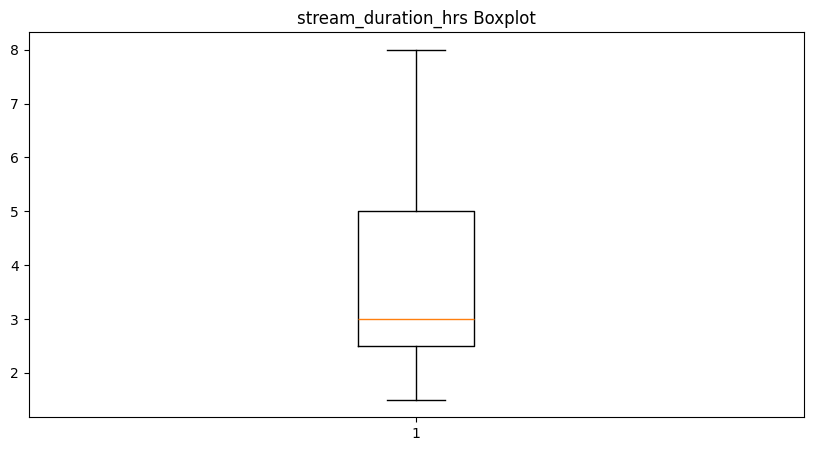

In [190]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streams["stream_duration_hrs"])
plt.title("stream_duration_hrs Boxplot")

The boxplot doe snot have any outliers and is skewed towards the bottom.

Text(0.5, 1.0, 'peak_viewers_cleaned Boxplot')

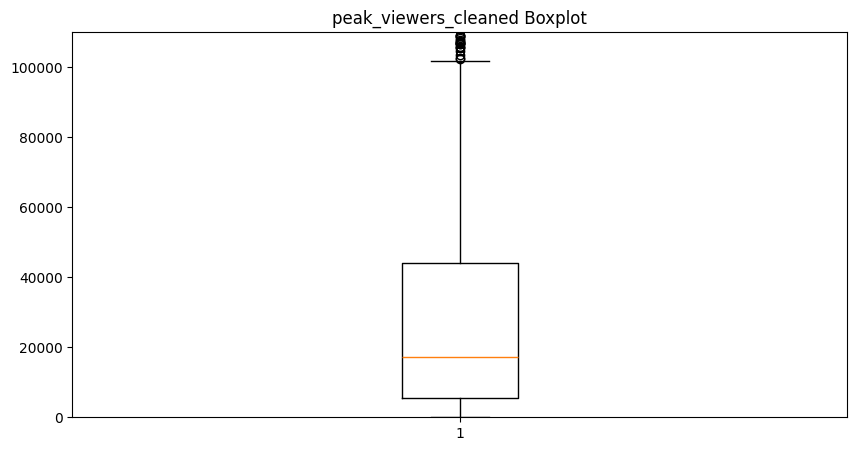

In [191]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streams["peak_viewers_cleaned"])
plt.ylim(0, 110000)
plt.title("peak_viewers_cleaned Boxplot")

This plot has a lot of outliers and the bottom whisker is at 0 and is skewed towards the bottom.

In [192]:
print(df_streams["category"].value_counts(), "\n")
print(df_streams["title_has_hype_word"].value_counts(), "\n")
print(df_streams["was_raid"].value_counts())

category
Just Chatting    273
FPS              201
Creative         190
Sports           176
MOBA             169
IRL              125
Name: count, dtype: int64 

title_has_hype_word
False    842
True     342
Name: count, dtype: int64 

was_raid
False    1019
True      165
Name: count, dtype: int64


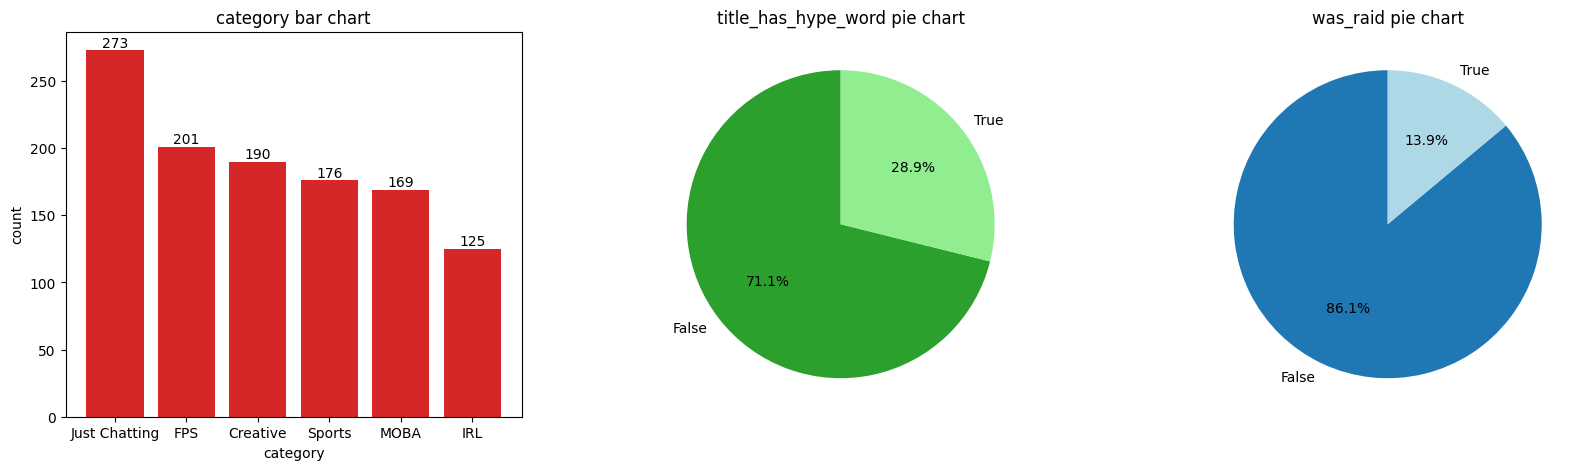

In [193]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

st_c_counts = df_streams["category"].value_counts()
st_c_bars = ax1.bar(st_c_counts.index.astype(str), st_c_counts.values, color="tab:red")
ax1.bar_label(st_c_bars)
ax1.set_title("category bar chart")
ax1.set_xlabel("category")
ax1.set_ylabel("count")

thhw_counts = df_streams["title_has_hype_word"].value_counts()
ax2.pie(
    thhw_counts.values, 
    labels=thhw_counts.index.astype(str), 
    autopct='%1.1f%%', 
    startangle=90,
    colors=["tab:green", "lightgreen"]
)
ax2.set_title("title_has_hype_word pie chart")

wr_counts = df_streams["was_raid"].value_counts()
ax3.pie(
    wr_counts.values, 
    labels=wr_counts.index.astype(str), 
    autopct='%1.1f%%', 
    startangle=90,
    colors=["tab:blue", "lightblue"]
)
ax3.set_title("was_raid pie chart")

plt.show()

Most streams are about Just Chatting, do not have the word hype in its names, and were not raided.

### viewers.csv

In [194]:
print("account_age_days stats: \n" +
      "median " + str(df_viewers["account_age_days"].median()) + "\n" +
      str(df_viewers["account_age_days"].describe()),"\n"
)

account_age_days stats: 
median 1966.5
count    1000.000000
mean     1881.119000
std      1036.144656
min        33.000000
25%       984.500000
50%      1966.500000
75%      2761.250000
max      3645.000000
Name: account_age_days, dtype: float64 



Text(0.5, 1.0, 'account_age_days Boxplot')

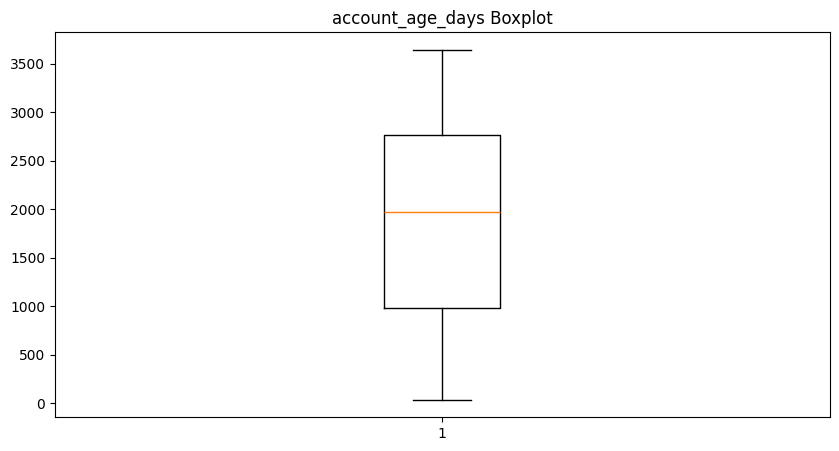

In [195]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_viewers["account_age_days"])
plt.title("account_age_days Boxplot")

This boxplot is slightly more towards the top. A lot of accounts are old in days.

In [196]:
print(df_viewers["age_group_cleaned"].value_counts(), "\n")
print(df_viewers["country"].value_counts(), "\n")
print(df_viewers["subscription_tier_cleaned"].value_counts(), "\n")
print(df_viewers["preferred_category"].value_counts())

age_group_cleaned
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64 

country
US       264
GB        82
CA        66
DE        53
BR        51
FR        47
KR        44
MX        40
other     38
JP        33
AU        31
IT        28
NL        22
ES        21
RU        20
AR        19
SE        19
IN        18
PL        17
TR         7
Name: count, dtype: int64 

subscription_tier_cleaned
free          578
tier1         248
tier2         100
tier3          49
premium        10
none            7
free trial      4
tier4           4
Name: count, dtype: int64 

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64


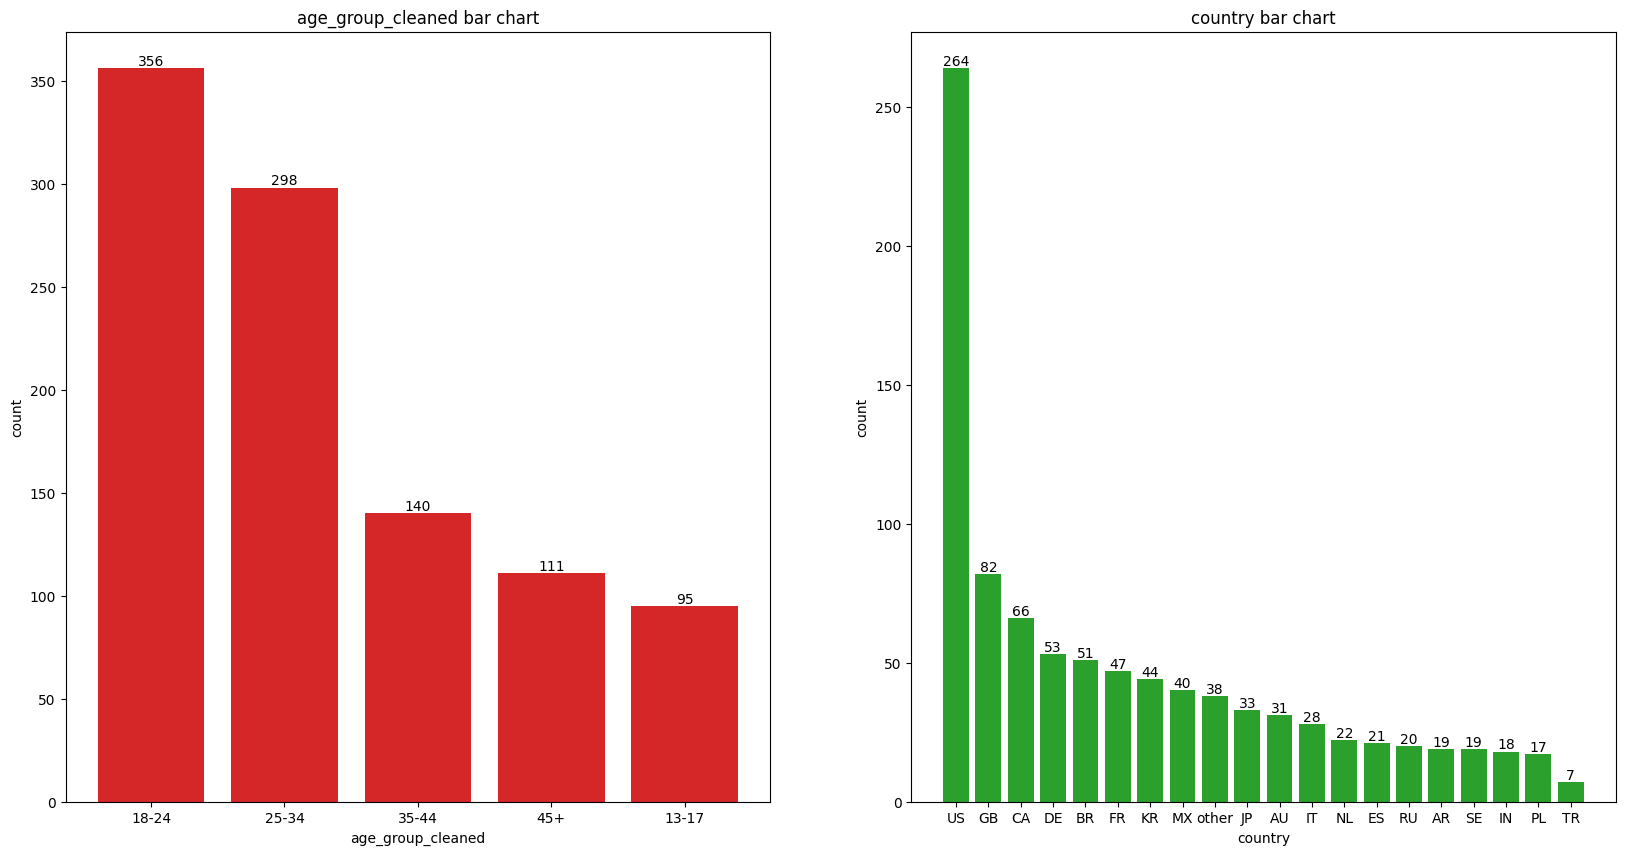

In [197]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ag_counts = df_viewers["age_group_cleaned"].value_counts()
ag_bars = ax1.bar(ag_counts.index.astype(str), ag_counts.values, color="tab:red")

ax1.bar_label(ag_bars)
ax1.set_title("age_group_cleaned bar chart")
ax1.set_xlabel("age_group_cleaned")
ax1.set_ylabel("count")

v_c_counts = df_viewers["country"].value_counts()
v_c_bars = ax2.bar(v_c_counts.index.astype(str), v_c_counts.values, color="tab:green")

ax2.bar_label(v_c_bars)
ax2.set_title("country bar chart")
ax2.set_xlabel("country")
ax2.set_ylabel("count")

plt.show()

Most Twitch viewers are 18-24 and are in the US.

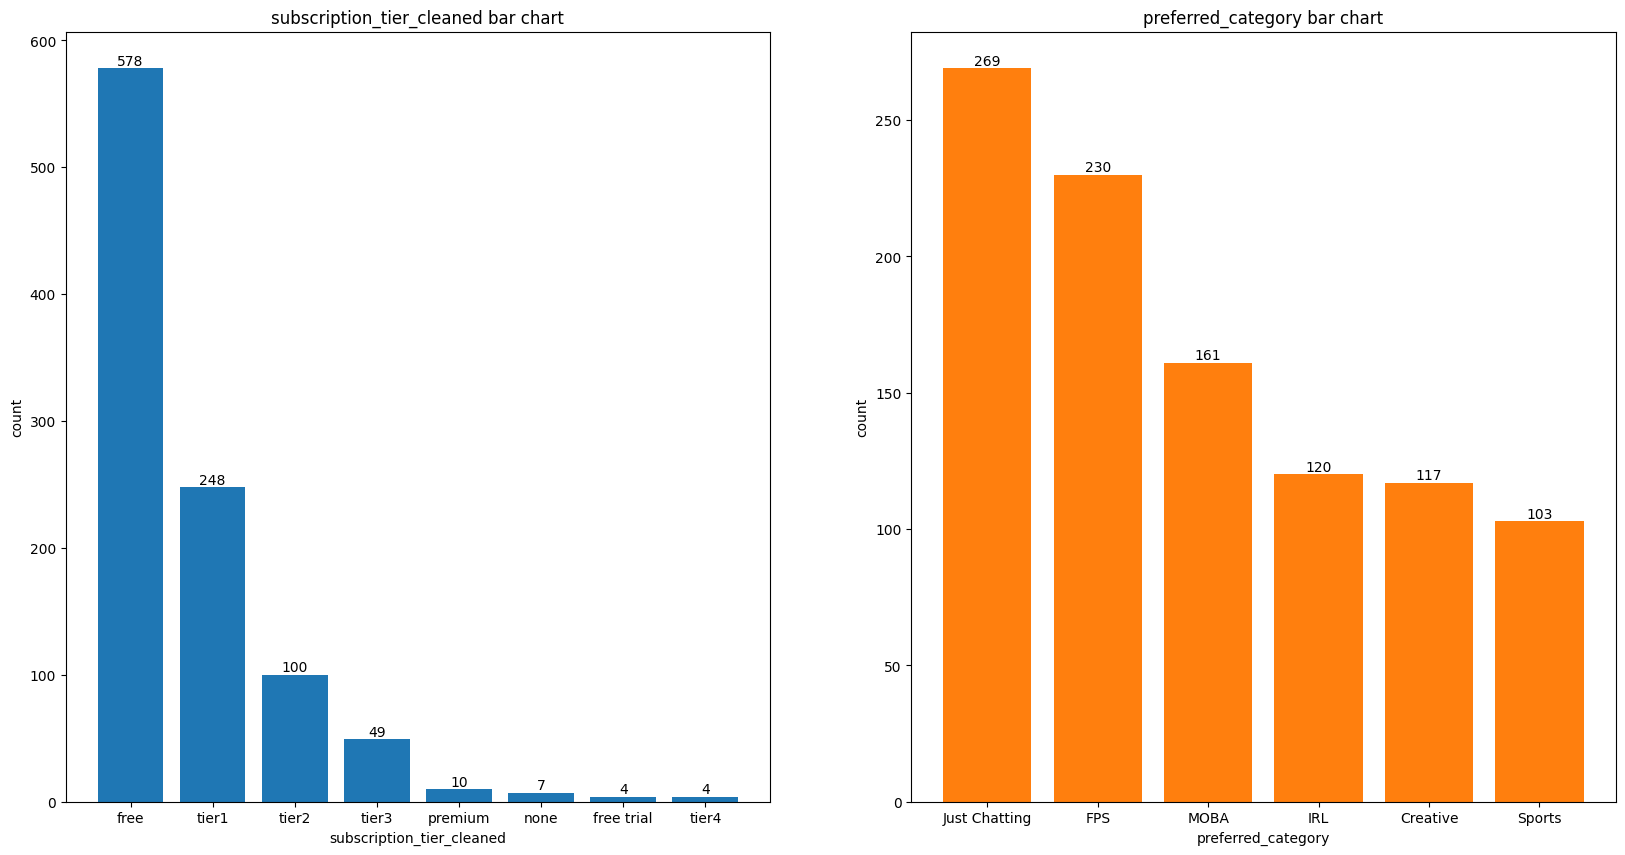

In [198]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

stc_counts = df_viewers["subscription_tier_cleaned"].value_counts()
stc_bars = ax1.bar(stc_counts.index.astype(str), stc_counts.values, color="tab:blue")

ax1.bar_label(stc_bars)
ax1.set_title("subscription_tier_cleaned bar chart")
ax1.set_xlabel("subscription_tier_cleaned")
ax1.set_ylabel("count")

pc_counts = df_viewers["preferred_category"].value_counts()
pc_bars = ax2.bar(pc_counts.index.astype(str), pc_counts.values, color="tab:orange")

ax2.bar_label(pc_bars)
ax2.set_title("preferred_category bar chart")
ax2.set_xlabel("preferred_category")
ax2.set_ylabel("count")

plt.show()

Most viewers have a free tier and have a preferred category of Just Chatting.

### streams.csv Overall Data

In [199]:
print(df_streams["stream_duration_hrs"].describe(), "\n")
print(df_streams["peak_viewers_cleaned"].describe())

count    1184.000000
mean        3.771537
std         1.596555
min         1.500000
25%         2.500000
50%         3.000000
75%         5.000000
max         8.000000
Name: stream_duration_hrs, dtype: float64 

count      1184.000000
mean      35686.377534
std       49548.068467
min           0.000000
25%        5609.750000
50%       17228.500000
75%       44104.750000
max      370165.000000
Name: peak_viewers_cleaned, dtype: float64


### Summary Statistics by age_group

In [200]:
df_stream_viewer = (
    df_sessions
    .merge(df_streams[["stream_id", "stream_duration_hrs", "peak_viewers_cleaned"]], on="stream_id")
    .merge(df_viewers[["viewer_id", "age_group_cleaned"]], on="viewer_id")
)

df_stream_viewer.groupby("age_group_cleaned")[["duration_mins", "chat_messages_sent", "bits_cheered"]].describe()

duration_mins                                               \
                          count       mean        std  min   25%   50%   75%   
age_group_cleaned                                                              
13-17                    2067.0  58.554427  59.211717  2.0  15.0  39.0  83.0   
18-24                    7813.0  58.939332  60.635670  2.0  16.0  39.0  82.0   
25-34                    6588.0  58.824985  59.781934  2.0  15.0  39.0  82.0   
35-44                    3075.0  60.163577  60.207986  2.0  16.0  40.0  84.5   
45+                      2758.0  58.924583  61.208256  2.0  15.0  38.0  81.0   

                         chat_messages_sent            ...              \
                     max              count      mean  ...  75%    max   
age_group_cleaned                                      ...               
13-17              414.0             2067.0  4.977262  ...  5.0  149.0   
18-24              443.0             7813.0  4.877896  ...  5.0  220.0   
25-34              436.0             6588.0  4.815877  ...  5.0  139.0   
35-44              392.0             3075.0  4.300163  ...  5.0  110.0   
45+                423.0             2758.0  5.545323  ...  6.0  126.0   

                  bits_cheered                                               \
                         count        mean          std  min  25%  50%  75%   
age_group_cleaned                                                             
13-17                   2067.0  419.708757  1584.209210  0.0  0.0  0.0  0.0   
18-24                   7813.0  395.350570  1560.565495  0.0  0.0  0.0  0.0   
25-34                   6588.0  389.630540  1553.593277  0.0  0.0  0.0  0.0   
35-44                   3075.0  353.531382  1507.029933  0.0  0.0  0.0  0.0   
45+                     2758.0  424.674764  1613.647587  0.0  0.0  0.0  0.0   

                            
                       max  
age_group_cleaned           
13-17               9977.0  
18-24               9992.0  
25-34              10000.0  
35-44               9987.0  
45+                 9924.0  

[5 rows x 24 columns]

This dataFrame combines the attributes of viewers and streams. 35-44 watches the most, 45+ chat the most, and 45+ cheered bits the most on average.

### Distribution of Stream Duration and Popular Categories

Text(0.5, 1.0, 'number of streams vs. stream_duration_hrs')

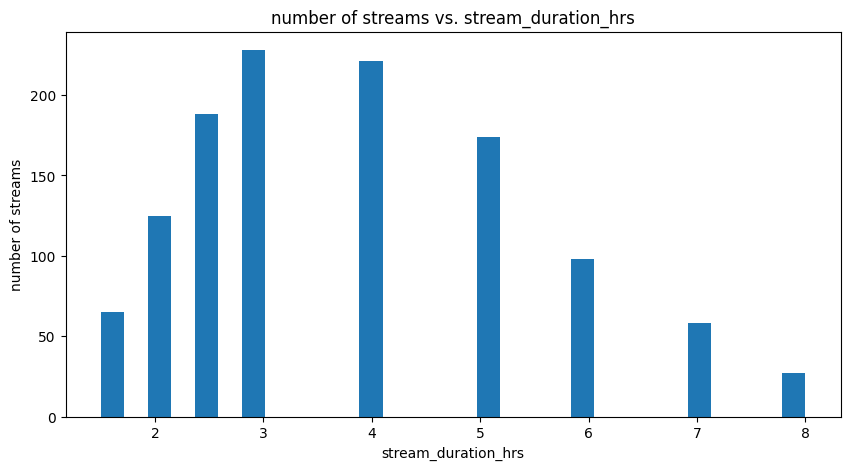

In [201]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["stream_duration_hrs"], bins=30)
plt.xlabel("stream_duration_hrs")
plt.ylabel("number of streams")
plt.title("number of streams vs. stream_duration_hrs")

Most streams usually last around 3 hours.

Text(0.5, 1.0, 'number of streams vs. category_cleaned')

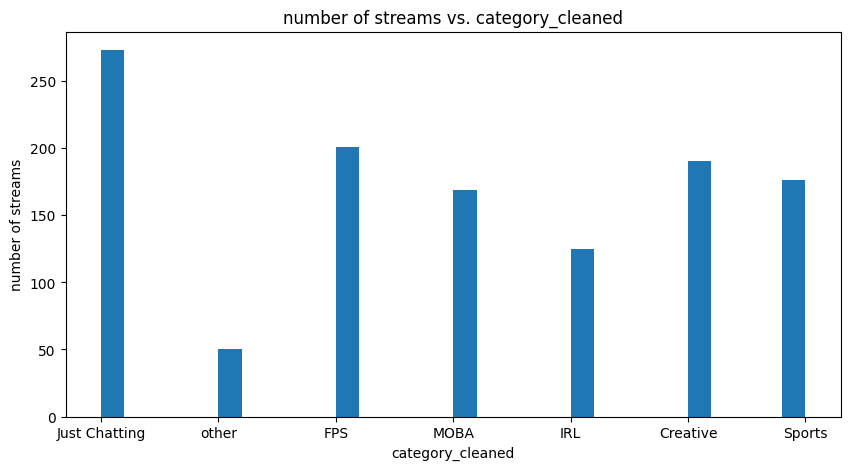

In [202]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["category_cleaned"], bins=30)
plt.xlabel("category_cleaned")
plt.ylabel("number of streams")
plt.title("number of streams vs. category_cleaned")

Most streams are usually about Just Chatting.

### Category Information

In [203]:
print(df_streamers["category"].value_counts(), "\n")
print(df_streams["category_cleaned"].value_counts(), "\n")
print(df_viewers["preferred_category"].value_counts())

category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9
Name: count, dtype: int64 

category_cleaned
Just Chatting    273
FPS              201
Creative         190
Sports           176
MOBA             169
IRL              125
other             50
Name: count, dtype: int64 

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64


In all of these columns, Just Chatting is the greatest by count.

In [204]:
df_streamers.groupby("category")[["total_followers_cleaned", "avg_concurrent_viewers"]].describe()

total_followers_cleaned                                         \
                                count          mean           std        min   
category                                                                       
Creative                         13.0  1.127692e+06  7.600675e+05   290000.0   
FPS                              13.0  4.012308e+06  3.703805e+06        0.0   
IRL                               9.0  3.423333e+06  3.660464e+06   380000.0   
Just Chatting                    18.0  3.742778e+06  4.421482e+06        0.0   
MOBA                             12.0  2.052500e+06  1.793839e+06   230000.0   
Sports                           11.0  5.581818e+06  5.332320e+06  1300000.0   

                                                            \
                     25%        50%        75%         max   
category                                                     
Creative        720000.0   940000.0  1500000.0   3100000.0   
FPS            1900000.0  2900000.0  6800000.0  11100000.0   
IRL             820000.0  1600000.0  4100000.0   9800000.0   
Just Chatting   600000.0  2250000.0  5575000.0  14500000.0   
MOBA            752500.0  1450000.0  2425000.0   5800000.0   
Sports         2150000.0  3800000.0  5800000.0  18700000.0   

              avg_concurrent_viewers                                      \
                               count          mean           std     min   
category                                                                   
Creative                        13.0   7856.000000   4980.053162  1011.0   
FPS                             13.0  34835.153846  41433.602810   678.0   
IRL                              9.0  32747.666667  39150.652006  2674.0   
Just Chatting                   18.0  44349.277778  45113.585936  3932.0   
MOBA                            12.0  17381.250000  17107.890153   634.0   
Sports                          11.0  46977.363636  48641.113094  4321.0   

                                                      
                    25%      50%       75%       max  
category                                              
Creative        5518.00   6870.0   9938.00   18345.0  
FPS            10414.00  14496.0  48998.00  141627.0  
IRL             6323.00  20511.0  38862.00  125683.0  
Just Chatting  10622.75  26943.5  65437.00  156401.0  
MOBA            5410.50   9279.0  25568.25   56574.0  
Sports         19208.50  31132.0  42696.00  151923.0

Sports has the most total followers on average and Just Chatting has the most average concurrent viewers.

In [205]:
df_streamers.groupby("category")["partner_status"].value_counts()

category       partner_status
Creative       True              10
               False              3
FPS            True              11
               False              2
IRL            True               7
               False              2
Just Chatting  True              17
               False              1
MOBA           True              10
               False              2
Sports         True              11
Name: count, dtype: int64

All categories has more partner_status True values than False.

In [206]:
df_streamers.groupby("category")["language_cleaned"].value_counts()

category       language_cleaned
Creative       English             12
               other                1
FPS            English             12
               other                1
IRL            English              7
               other                2
Just Chatting  English             13
               Spanish              4
               other                1
MOBA           English              9
               other                2
               Korean               1
Sports         English              8
               Portuguese           1
               other                1
               Spanish              1
Name: count, dtype: int64

English is used the most in each category.

### Task 3 Summary report

**User Characteristics**

- Sessions average 59 minutes but tend to skew shorter; chat, bits, follows, and subscriptions are rare
- Viewers are mostly young adults from the US on free accounts

**Streams Data Overall and by Group**

- Streams typically last 3 hours; peak viewership is highly right-skewed (median 19,700 vs. mean 38,200), indicating that a few streams draw outsized audiences

**Distribution of Stream Durations and Popular Categories**

- Durations cluster around 2.5-3 hours. Just Chatting leads in stream count, followed by FPS, Creative, Sports, MOBA, and IRL—mirroring viewer preferences

**Category-Specific Information and Streamer Comparison**

- Just Chatting has the most streamers (18) and the highest follower counts; other categories range from 9-13 streamers with wide variation in viewership within each

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


### Missing Values or Outliers in Original Data

The streamers.csv section in Task 2 mentions that total_followers and language columns had NaN values and were replaced with 0 and "other" values respectively.

The streams.csv section in Task 2 mentions that peak_viewers and category columns had NaN values and were replaced with 0 and "other" values respectively.

The viewers.csv section in Task 2 mentions that the country column had NaN values and were replaced with "other" values.

---

In Task 3, all of the outliers across the four .csv files have outliers above the boxplots when plotted vertically. These outliers are:
- sessions.csv duration_mins
- sessions.csv chat_messages_sent
- sessions.csv bits_cheered
- streamers.csv total_followers (after it was cleaned)
- streamers.csv avg_concurrent_viewers
- streams.csv peak_viewers (after it was cleaned)

### Missing Values or Outliers in Derived Data

In [207]:
len(df_sessions)

22644

The sessions.csv section in Task 2 mentions that streamer_id had several NaN values and were deleted. There were 22825 rows and now there are 22644 rows from the streamer_id deletion and miscaculated duration_mins values.

---

In Task 3, all of the outliers across the four .csv files have outliers above the boxplots when plotted vertically. These outliers are:
- sessions.csv duration_mins

### Strategies for Inputing Missing Values

- I dealt with values that had NaNs by changing there values to 0 or "other" depending on the column.
    - In Task 3, I ploted a histogram about viewers.csv country. This showed an other bin in the plot. In this case, this means that there is a section of viewers that are from a  differnt country not listed in the data.
- I also deleted rows that had values of NaN (eg. streamer_id NaN values).
    - In Task 2 I deleted streamer_id with NaN values. This got rid of ususable data. The majority of the data is unchanged because only 60 rows with NaN stremaer_id values were deleted in Task 2.

### Strategies for Handeling Outliers

Text(0.5, 1.0, 'duration_mins Boxplot')

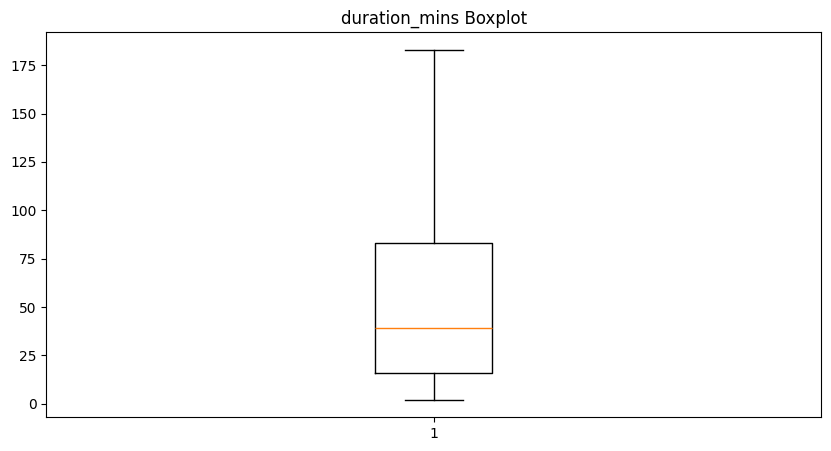

In [208]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["duration_mins"], showfliers=False)
plt.title("duration_mins Boxplot")

- By added showfliers=False in the boxplot, there is no need to zoom in (plt.ylim()) on the plot.
    - If I were to just delete the outliers in the data and plot it again, this would change the summary statistics and new outliers will be created.

Text(0.5, 1.0, 'duration_mins_capped Boxplot')

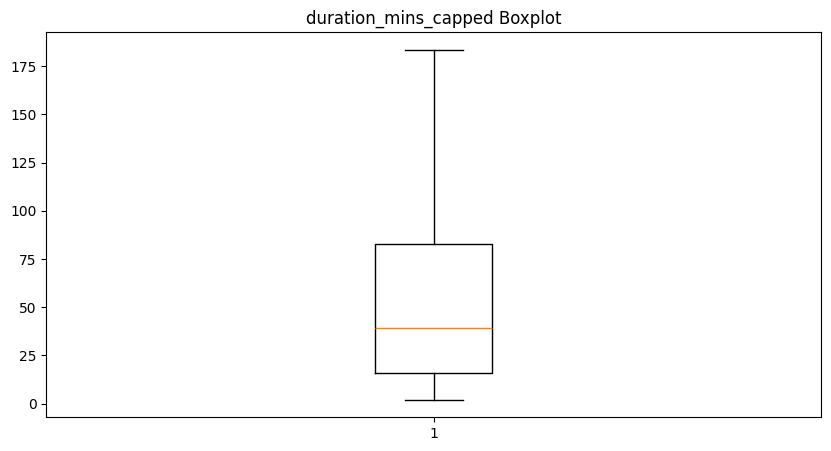

In [209]:
Q1 = df_sessions["duration_mins"].quantile(0.25)
Q3 = df_sessions["duration_mins"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_sessions["duration_mins_capped"] = np.clip(df_sessions["duration_mins"], lower_bound, upper_bound)
df_sessions["duration_mins_capped"]

plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["duration_mins_capped"], showfliers=False)
plt.title("duration_mins_capped Boxplot")

- By capping the outliers by replace there values with the min or max values will not change the boxplot.
    - Compared to getting rid of the outliers, this keeps the number of rows intact.

### Task 4 Summary report

**Original Data Analysis**

- Missing values were found across multiple datasets (handled by replacing them with 0 or "other") and significant right-skewed outliers were detected above the boxplots in columns like duration_mins, total_followers, and peak_viewers

**Derived Data Analysis**

- Critical missing identifiers (streamer_id) and miscalculated records were permanently deleted (reducing rows from 22825 to 22644), though substantial outliers still remain in the derived duration_mins column

**Mitigation Strategies & Impact**

- Missing data was addressed via constant filling (preserving rows but adding an "other" category) and deletion (removing unusable rows)
- Outliers were managed via visual suppression using showfliers=False (cleaning the plot without altering data) and capping (compressing extreme values while keeping row counts intact)

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

### Pairwise Correlations

In [210]:
checkins = df_sessions.groupby("viewer_id").size().rename("num_checkins")

session_agg = df_sessions.groupby("viewer_id").agg(
    avg_duration_mins=("duration_mins", "mean"),
    total_chat_messages=("chat_messages_sent", "sum"),
    total_bits_cheered=("bits_cheered", "sum"),
    follow_rate=("followed_during", "mean"),
    subscribe_rate=("subscribed_during", "mean"),
).join(checkins)

age_order = {"13-17": 1, "18-24": 2, "25-34": 3, "35-44": 4, "45+": 5}
tier_order = {"none": 0, "free": 0, "free trial": 0, "tier1": 1, "tier2": 2, "tier3": 3, "tier4": 4, "premium": 5}

viewer_features = df_viewers[["viewer_id", "account_age_days", "age_group_cleaned", "subscription_tier_cleaned"]].copy()
viewer_features["age_group_encoded"] = viewer_features["age_group_cleaned"].map(age_order)
viewer_features["subscription_tier_encoded"] = viewer_features["subscription_tier_cleaned"].map(tier_order)

df_user = viewer_features.merge(session_agg.reset_index(), on="viewer_id")

numeric_cols = [
    "account_age_days", "age_group_encoded", "subscription_tier_encoded",
    "num_checkins", "avg_duration_mins", "total_chat_messages",
    "total_bits_cheered", "follow_rate", "subscribe_rate",
]
df_numeric = df_user[numeric_cols].dropna()

pearson_corr = df_numeric.corr(method="pearson")
print("Pearson Correlation Matrix:")
print(pearson_corr.round(3))

Pearson Correlation Matrix:
                           account_age_days  age_group_encoded  \
account_age_days                      1.000              0.047   
age_group_encoded                     0.047              1.000   
subscription_tier_encoded             0.068              0.010   
num_checkins                         -0.024              0.028   
avg_duration_mins                    -0.029             -0.027   
total_chat_messages                   0.027              0.029   
total_bits_cheered                   -0.030              0.010   
follow_rate                          -0.049              0.006   
subscribe_rate                        0.009              0.046   

                           subscription_tier_encoded  num_checkins  \
account_age_days                               0.068        -0.024   
age_group_encoded                              0.010         0.028   
subscription_tier_encoded                      1.000        -0.017   
num_checkins                   

### Correlation Matrix

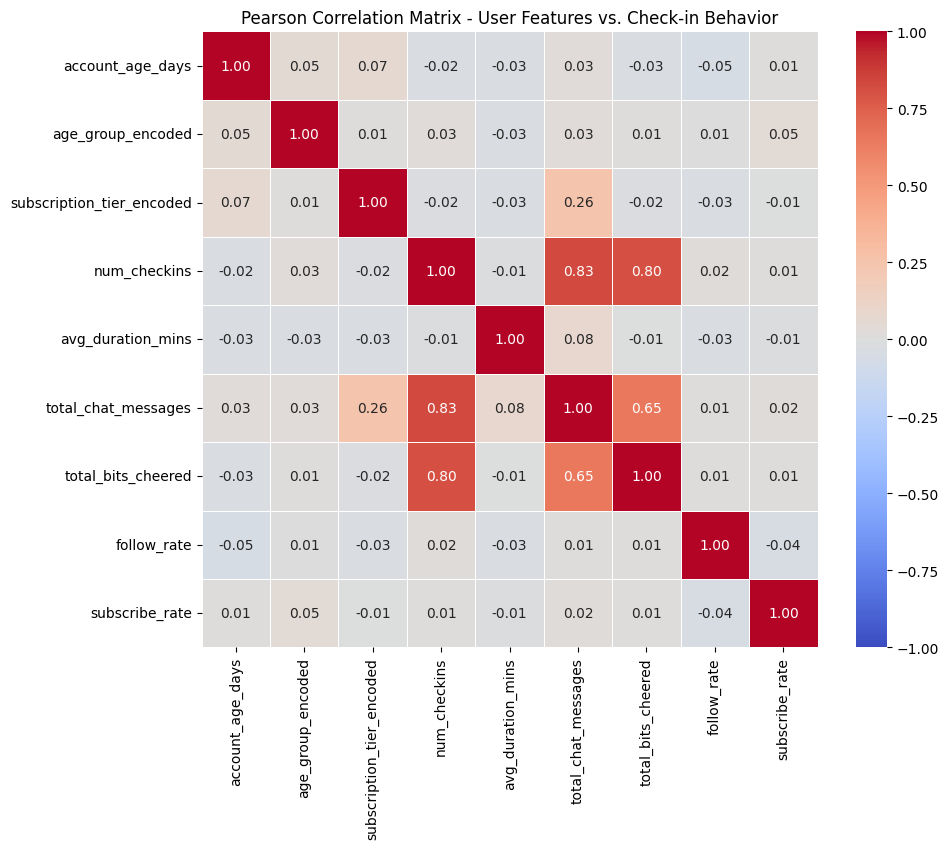

In [211]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix - User Features vs. Check-in Behavior")
plt.show()

num_checkins has a high positive correlation with total_chat_messages and total_bits_cheered. There is liitle positve correlation with subscription_tier_encoded with total_chat_messages.

### Spearman Rank Correlation

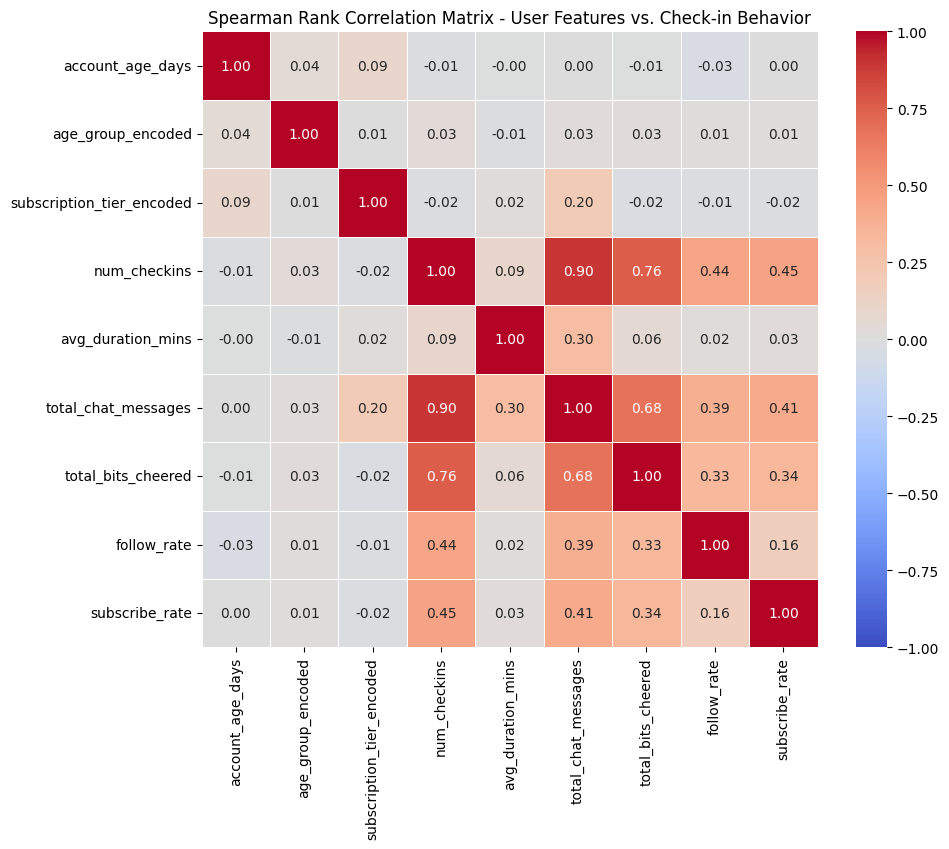

In [212]:
spearman_corr = df_numeric.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Spearman Rank Correlation Matrix - User Features vs. Check-in Behavior")
plt.show()

- The Spearman correlation matrix has a greater number of more positive correlation than Pearson. total_chat_messages, total_bits_cheered, and num_checkins are all heavily skewed to the top higher values.
- Most viewers have very low values with a small number of extreme outliers. Pearson is sensitive to these outliers because it uses raw values. On the other hand, Spearman cares about rank order.
- age_group_encoded and subscription_tier_encoded are ordinal, but the numeric gaps between levels are not meaningful. Spearman considers order without assuming equal spacing between values.
- Spearman captures non linear trends where Pearson would understate it by only measuring the linear component.

### Task 5 Summary report

Pairwise Correlations

- Check ins correlate highest with chat messages and bits because more visits create more chances to interact
- Age and subscription tier show zero correlation with check ins, proving demographics do not predict attendance
- Follow and subscription rates align positively, meaning active viewers generally do both

Spearman vs. Pearson

- Spearman shows the same directional trends as Pearson but with stronger correlation values for behavior
- Spearman is better for behavioral data because its rank based system handles heavy skew and extreme outliers
- Spearman fits encoded categories better because rank order matters more than the raw numeric spacing
- Spearman successfully captures non linear trends that Pearson underestimates

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

### User Group Segments

In [ ]:
print("--- Age Group Segments ---")
print(df_viewers["age_group_cleaned"].value_counts())

tier_map = {
    "free": "free",
    "none": "free",
    "free trial": "free",
    "tier1": "paid",
    "tier2": "paid",
    "tier3": "paid",
    "tier4": "paid",
    "premium": "paid",
}
df_viewers["tier_group"] = df_viewers["subscription_tier_cleaned"].map(tier_map)

print("\n--- Subscription Tier Segments ---")
print(df_viewers["tier_group"].value_counts())

terciles = df_viewers["account_age_days"].quantile([1/3, 2/3])
def label_account_age(days):
    if days <= terciles[1/3]:
        return "new"
    elif days <= terciles[2/3]:
        return "mid"
    else:
        return "old"

df_viewers["account_age_group"] = df_viewers["account_age_days"].apply(label_account_age)

print("\n--- Account Age Segments ---")
print(df_viewers["account_age_group"].value_counts())

--- Age Group Segments ---
age_group_cleaned
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64

--- Subscription Tier Segments ---
tier_group
free    589
paid    411
Name: count, dtype: int64

--- Account Age Segments ---
account_age_group
new    334
mid    333
old    333
Name: count, dtype: int64


**Age group** (age_group_cleaned)
- Already cleaned in Task 1

**Subscription tier** (tier_group)
- The eight tier values from Task 2 are collapsed into two groups: free (free, none, free trial) and paid (tier1-4, premium).
    - This separates passive viewers from those who financially support streamers

**Account age** (account_age_group)
- Split into thirds by quantile: new (bottom third), mid (middle third), old (top third)
    - Terciles are used rather than fixed day thresholds so each group has roughly equal size, making comparisons fair

### Viewing Behaviour Boxplots

In [246]:
df_vb_seg = df_sessions.merge(
    df_viewers[["viewer_id", "age_group_cleaned", "subscription_tier_cleaned", "tier_group", "account_age_group"]], 
    on="viewer_id"
)

Merge segments onto session data

C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\4188528014.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_age, labels=age_order, showfliers=False)


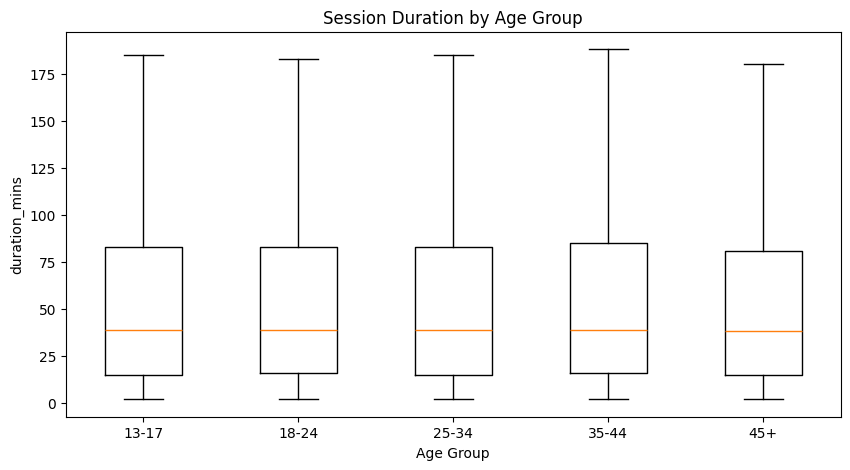

In [215]:
age_order = ["13-17", "18-24", "25-34", "35-44", "45+"]
data_by_age = [df_vb_seg[df_vb_seg["age_group_cleaned"] == g]["duration_mins"].dropna() for g in age_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_by_age, labels=age_order, showfliers=False)
ax.set_title("Session Duration by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("duration_mins")
plt.show()

**Session Duration by Age Group:**
- All age groups have a similar median watch time (~35–45 min), meaning age alone does not strongly predict how long someone watches per session.

C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\1723770512.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_tier, labels=tier_order, showfliers=False)


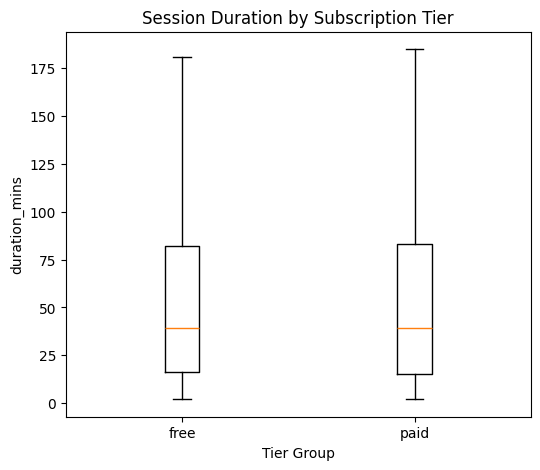

In [216]:
tier_order = ["free", "paid"]
data_by_tier = [df_vb_seg[df_vb_seg["tier_group"] == g]["duration_mins"].dropna() for g in tier_order]

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(data_by_tier, labels=tier_order, showfliers=False)
ax.set_title("Session Duration by Subscription Tier")
ax.set_xlabel("Tier Group")
ax.set_ylabel("duration_mins")
plt.show()

**Session Duration by Subscription Tier:**
- Paid subscribers tend to watch slightly longer than free viewers.
- Paying for a tier implies intent to engage more, so longer sessions align with that commitment.

C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\2573245525.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_acct, labels=acct_order, showfliers=False)


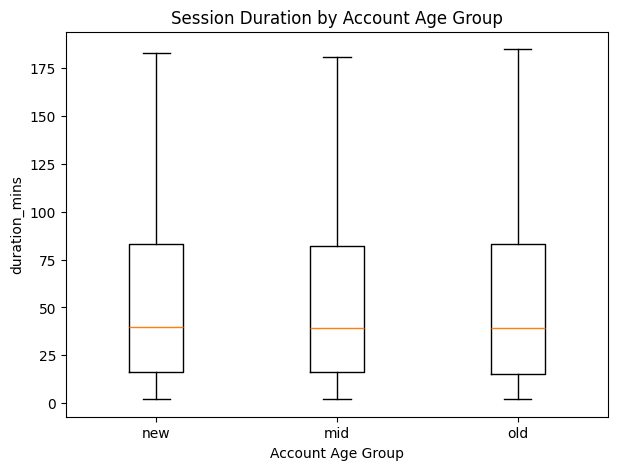

In [217]:
acct_order = ["new", "mid", "old"]
data_by_acct = [df_vb_seg[df_vb_seg["account_age_group"] == g]["duration_mins"].dropna() for g in acct_order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data_by_acct, labels=acct_order, showfliers=False)
ax.set_title("Session Duration by Account Age Group")
ax.set_xlabel("Account Age Group")
ax.set_ylabel("duration_mins")
plt.show()

**Session Duration by Account Age Group:**
- Old accounts have a marginally higher median duration than new accounts.
- Longer-tenured viewers may have settled into consistent, longer viewing habits.

C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\3567679054.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_chat_age, labels=age_order, showfliers=False)


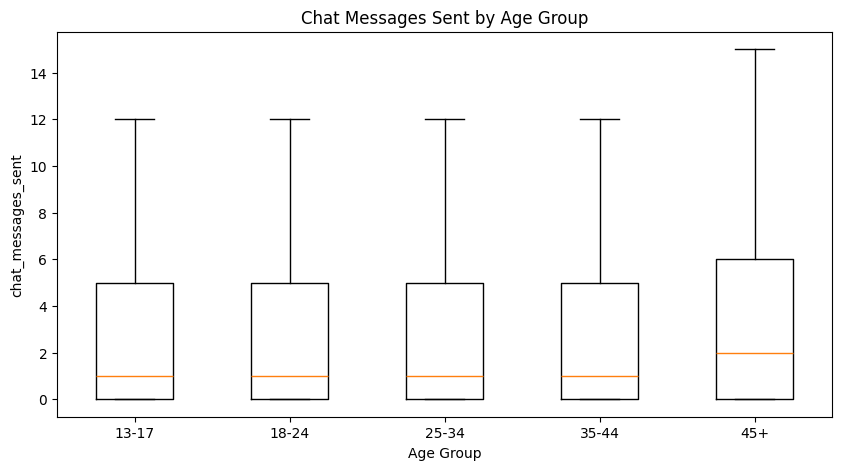

In [218]:
data_chat_age = [df_vb_seg[df_vb_seg["age_group_cleaned"] == g]["chat_messages_sent"].dropna() for g in age_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_chat_age, labels=age_order, showfliers=False)
ax.set_title("Chat Messages Sent by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("chat_messages_sent")
plt.show()

**Chat Messages Sent by Age Group:**
- The 45+ group sends slightly more chat messages than younger groups despite having fewer total viewers.
- Older viewers may be more verbally engaged per session.

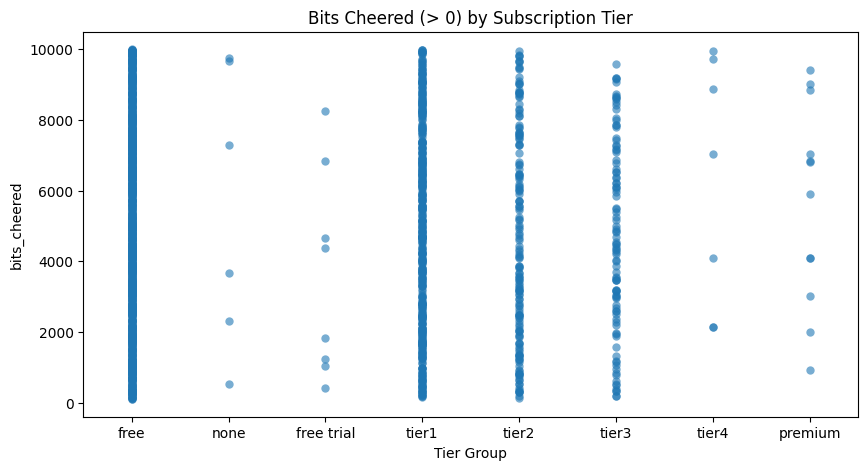

In [255]:
tiers = [
    "free",
    "none",
    "free trial",
    "tier1",
    "tier2",
    "tier3",
    "tier4",
    "premium",
]
fig, ax = plt.subplots(figsize=(10, 5))

sns.stripplot(
    data=df_vb_seg[df_vb_seg["bits_cheered"] > 0], 
    x="subscription_tier_cleaned", 
    y="bits_cheered", 
    order=tiers,
    jitter=False, 
    size=6, 
    alpha=0.6,
    ax=ax
)

ax.set_title("Bits Cheered (> 0) by Subscription Tier")
ax.set_xlabel("Tier Group")
ax.set_ylabel("bits_cheered")

plt.show()

**Bits Cheered by Subscription Tier:**
- Most of the data have 0 values which are not included in the dot plot.
    - 92% of the data has 0 values.
- The most fequent amount fo values are in the free and tier1 categories.
- tier1 is the most frequent paid category.

### Outliers in Group Behavior

In [220]:
def flag_outliers(df, group_col, value_col):
    """Return rows that fall outside 1.5 * IQR within their segment group."""
    result = []
    for grp, subset in df.groupby(group_col):
        Q1 = subset[value_col].quantile(0.25)
        Q3 = subset[value_col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (subset[value_col] < Q1 - 1.5 * IQR) | (subset[value_col] > Q3 + 1.5 * IQR)
        flagged = subset[mask].copy()
        flagged["segment"] = grp
        result.append(flagged)
    return pd.concat(result)

outliers_age  = flag_outliers(df_vb_seg, "age_group_cleaned", "duration_mins")
outliers_tier = flag_outliers(df_vb_seg, "tier_group",        "duration_mins")
outliers_bits = flag_outliers(df_vb_seg, "tier_group",        "bits_cheered")

print("Outlier counts - duration_mins by age group:")
print(outliers_age.groupby("segment").size(), "\n")

print("Outlier counts - duration_mins by tier group:")
print(outliers_tier.groupby("segment").size(), "\n")

print("Outlier counts - bits_cheered by tier group:")
print(outliers_bits.groupby("segment").size())

Outlier counts - duration_mins by age group:
segment
13-17    110
18-24    402
25-34    317
35-44    161
45+      140
dtype: int64 

Outlier counts - duration_mins by tier group:
segment
free    677
paid    476
dtype: int64 

Outlier counts - bits_cheered by tier group:
segment
free    1082
paid     723
dtype: int64


The flag_outliers function applies the standard IQR rule (values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR) within each segment group separately, so an outlier is extreme relative to peers in the same group, not just globally.

C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\3883072417.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\3883072417.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


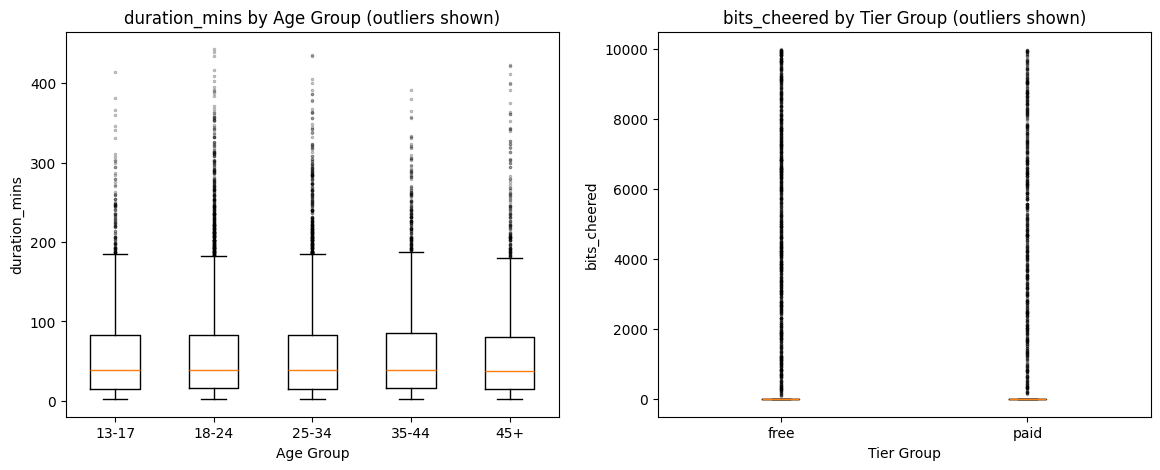

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_order  = ["13-17", "18-24", "25-34", "35-44", "45+"]
tier_order = ["free", "paid"]

axes[0].boxplot(
    [df_vb_seg[df_vb_seg["age_group_cleaned"] == g]["duration_mins"].dropna() for g in age_order],
    labels=age_order,
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
)
axes[0].set_title("duration_mins by Age Group (outliers shown)")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("duration_mins")

axes[1].boxplot(
    [df_vb_seg[df_vb_seg["tier_group"] == g]["bits_cheered"].dropna() for g in tier_order],
    labels=tier_order,
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
)
axes[1].set_title("bits_cheered by Tier Group (outliers shown)")
axes[1].set_xlabel("Tier Group")
axes[1].set_ylabel("bits_cheered")

plt.show()

Age group outlier counts are broadly proportional to segment size (18–24 and 25–34 have the most simply because they are the largest groups). The extreme values all sit at the high end — these are viewers who watched for several hours in a single session.

The bits_cheered paid segment produces more bits outliers in the free than the paid category.

In [222]:
top_duration = (
    outliers_age
    .nlargest(10, "duration_mins")
    [["viewer_id", "age_group_cleaned", "duration_mins", "chat_messages_sent", "bits_cheered"]]
)
print("\nTop 10 duration outliers:")
print(top_duration.to_string(index=False))


Top 10 duration outliers:
viewer_id age_group_cleaned  duration_mins  chat_messages_sent  bits_cheered
 VWR00895             18-24            443                  14             0
 VWR00921             18-24            439                  41             0
 VWR00082             25-34            436                   2             0
 VWR00813             18-24            434                  94             0
 VWR00899             25-34            434                   1             0
 VWR00844               45+            423                  42             0
 VWR00942               45+            422                  14             0
 VWR00390             18-24            417                  61             0
 VWR00539             13-17            414                 145           779
 VWR00869               45+            412                  18             0


Looking at the top 10, they tend to also have elevated chat_messages_sent, suggesting they are genuinely highly engaged viewers rather than streams left playing unattended.

In [223]:
top_bits = (
    outliers_bits
    .nlargest(10, "bits_cheered")
    [["viewer_id", "tier_group", "bits_cheered", "duration_mins", "chat_messages_sent"]]
)
print("\nTop 10 bits_cheered outliers:")
print(top_bits.to_string(index=False))


Top 10 bits_cheered outliers:
viewer_id tier_group  bits_cheered  duration_mins  chat_messages_sent
 VWR00744       free         10000             47                  17
 VWR00721       free          9992            129                   4
 VWR00926       free          9991             36                   2
 VWR00854       free          9988             70                   7
 VWR00791       paid          9987             54                  16
 VWR00807       free          9977            247                   4
 VWR00809       paid          9970             16                   0
 VWR00967       free          9966            193                  16
 VWR00899       paid          9965            255                   6
 VWR00807       free          9959              9                   0


The top 10 all hit the dataset maximum of 10,000 bits in a single session. This is consistent. Viewers willing to pay a subscription are also the ones most likely to make large one-off bits purchases. These are not data errors; they represent a small high spending audience whose behaviour is distinct from the typical paid subscriber.

### Task 6 Summary report

**Segmentation**
- Age Groups splits into five brackets from 13 to 45+.
- Subscription Tiers are simplified into free vs. paid accounts.
- Account Age are categorized into new, mid, and old tiers using quantiles.

**Viewing Behavior Across Segments**
- Session durations remain stable across all age groups, showing that age does not predict viewing lengths.
- Paid subscribers watch slightly longer and cheer substantially more bits than free viewers, reflecting higher overall financial engagement.
- Old accounts hold a marginally higher median watch time, suggesting more established viewing habits.
- The 45+ age bracket sends slightly more chat messages per session than younger groups, despite being a smaller segment.

**Outliers**
- Extreme watch times (300+ minutes) appear across all age groups and pair with high chat activity, confirming viewers are active rather than leaving streams idle.
- Top tier bits cheered outliers hit the 10,000 maximum per session and are concentrated entirely within paid accounts, highlighting a distinct high spending viewer subset.

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


### Question 1: Does the time of day a session starts (morning vs. afternoon vs. evening) affect how long viewers watch?

In [224]:
def assign_time_period(hour):
    if 6 <= hour < 12:
        return "Morning (6-11)"
    elif 12 <= hour < 18:
        return "Afternoon (12-17)"
    else:
        return "Evening (18-5)"

df_sessions["start_hour"] = df_sessions["started_at"].dt.hour
df_sessions["time_period"] = df_sessions["start_hour"].apply(assign_time_period)

period_order = ["Morning (6-11)", "Afternoon (12-17)", "Evening (18-5)"]

time_stats = (
    df_sessions.groupby("time_period")["duration_mins"]
    .agg(count="count", mean="mean", median="median", std="std")
    .reindex(period_order)
)

print("--- Session Duration (mins) by Time of Day ---")
print(time_stats.round(2))

--- Session Duration (mins) by Time of Day ---
                   count   mean  median    std
time_period                                   
Morning (6-11)      3772  69.24    47.0  68.40
Afternoon (12-17)   8850  59.32    40.0  59.73
Evening (18-5)     10022  55.44    36.0  57.27


started_at is used to extract the hour of each session start, which is then bucketed into three periods: Morning (6-11 h), Afternoon (12-17 h), and Evening (18-5 h). The table reports the session count, mean, median, and standard deviation of duration_mins for each period, giving a first look at whether watch time differs across the day.

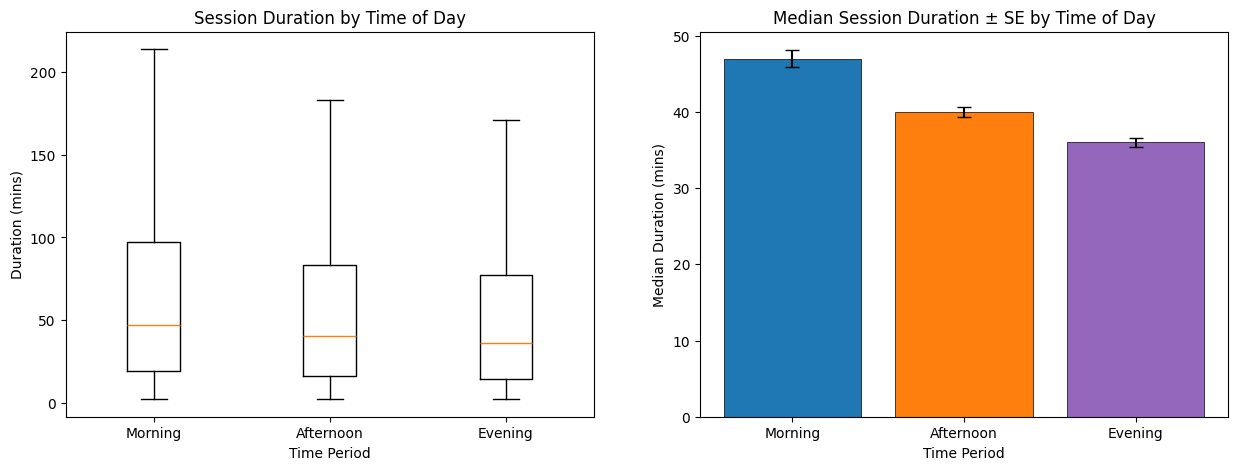

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

groups = [df_sessions[df_sessions["time_period"] == p]["duration_mins"] for p in period_order]
axes[0].boxplot(groups, tick_labels=[p.split(" ")[0] for p in period_order], showfliers=False)
axes[0].set_title("Session Duration by Time of Day")
axes[0].set_xlabel("Time Period")
axes[0].set_ylabel("Duration (mins)")

medians = time_stats["median"]
stds    = time_stats["std"]
x_pos   = range(len(period_order))
labels  = [p.split(" ")[0] for p in period_order]

axes[1].bar(x_pos, medians, yerr=stds / (time_stats["count"] ** 0.5),
            capsize=5, color=["tab:blue", "tab:orange", "tab:purple"], edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title("Median Session Duration ± SE by Time of Day")
axes[1].set_xlabel("Time Period")
axes[1].set_ylabel("Median Duration (mins)")

plt.show()

The boxplot shows the spread of duration_mins across all three periods without extreme outliers, while the bar chart highlights the median and standard error so small differences remain visible. If evening sessions have a noticeably higher median than morning or afternoon sessions, this would suggest that viewers who start watching late in the day tend to commit longer stretches of time. Possibly because evening hours carry fewer interruptions from work or school.

### Additional data that would help

- started_at is stored in a single timezone, so "morning" for one viewer is "evening" for another; knowing each viewer’s local time zone is essential to make the hour of day grouping meaningful.
- Pairing time of day with weekday vs. weekend would reveal whether the pattern is driven by schedule constraints rather than time of day alone.

### Question 2: Are viewers who send more chat messages or cheer more bits more likely to follow or subscribe during a session?

In [226]:
follow_stats = df_sessions.groupby("followed_during")[
    ["chat_messages_sent", "bits_cheered"]
].agg(["mean", "median", "std"])

sub_stats = df_sessions.groupby("subscribed_during")[
    ["chat_messages_sent", "bits_cheered"]
].agg(["mean", "median", "std"])

print("--- Engagement grouped by followed_during ---")
print(follow_stats)
print("\n--- Engagement grouped by subscribed_during ---")
print(sub_stats)

--- Engagement grouped by followed_during ---
                chat_messages_sent                   bits_cheered         \
                              mean median        std         mean median   
followed_during                                                            
False                     4.879607    1.0   9.942693   397.307986    0.0   
True                      5.019031    1.0  11.462477   400.002595    0.0   

                              
                         std  
followed_during               
False            1568.654066  
True             1598.455055  

--- Engagement grouped by subscribed_during ---
                  chat_messages_sent                   bits_cheered         \
                                mean median        std         mean median   
subscribed_during                                                            
False                       4.876430    1.0  10.005589   394.064622    0.0   
True                        5.408676    2.0  10.993429   

Sessions are split by followed_during and subscribed_during to compare the median engagement level of viewers who did and did not take a commitment action during that session.

C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\3992012375.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["Did Not Follow", "Followed"])
C:\Users\2003c\AppData\Local\Temp\ipykernel_9760\3992012375.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Did Not Subscribe", "Subscribed"])


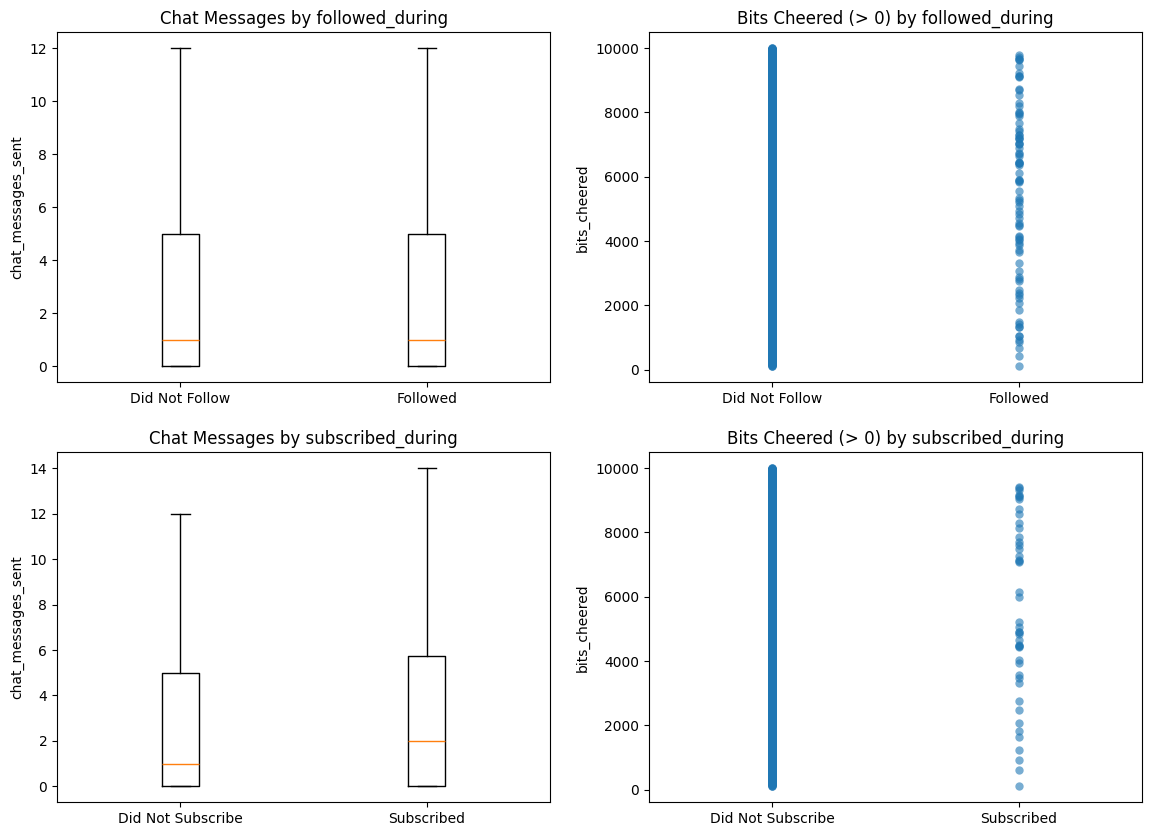

In [256]:
no_follow_chat  = df_sessions[df_sessions["followed_during"] == False]["chat_messages_sent"]
yes_follow_chat = df_sessions[df_sessions["followed_during"] == True]["chat_messages_sent"]

no_sub_chat  = df_sessions[df_sessions["subscribed_during"] == False]["chat_messages_sent"]
yes_sub_chat = df_sessions[df_sessions["subscribed_during"] == True]["chat_messages_sent"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].boxplot([no_follow_chat, yes_follow_chat], tick_labels=["Did Not Follow", "Followed"], showfliers=False)
axes[0, 0].set_title("Chat Messages by followed_during")
axes[0, 0].set_ylabel("chat_messages_sent")

sns.stripplot(
    data=df_sessions[df_sessions["bits_cheered"] > 0],
    x="followed_during",
    y="bits_cheered",
    order=[False, True],
    jitter=False,
    size=6,
    alpha=0.6,
    ax=axes[0, 1]
)
axes[0, 1].set_xticklabels(["Did Not Follow", "Followed"])
axes[0, 1].set_title("Bits Cheered (> 0) by followed_during")
axes[0, 1].set_xlabel("")

axes[1, 0].boxplot([no_sub_chat, yes_sub_chat], tick_labels=["Did Not Subscribe", "Subscribed"], showfliers=False)
axes[1, 0].set_title("Chat Messages by subscribed_during")
axes[1, 0].set_ylabel("chat_messages_sent")

sns.stripplot(
    data=df_sessions[df_sessions["bits_cheered"] > 0],
    x="subscribed_during",
    y="bits_cheered",
    order=[False, True],
    jitter=False,
    size=6,
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_xticklabels(["Did Not Subscribe", "Subscribed"])
axes[1, 1].set_title("Bits Cheered (> 0) by subscribed_during")
axes[1, 1].set_xlabel("")

plt.show()

Viewers who are followed or subscribed are slightly more engaged that those who are not followed or subscribed. However, those who did not follow or subscribed had higher bits cheered than those who followed or subscribed.

#### Additional Data That Would Help

- Distinguishing a viewer's first visit (curiosity driven follows) from their tenth (loyalty driven subscriptions) would clarify whether engagement causes commitment or both are driven by prior familiarity.
- Streamers often prompt follows at specific moments, which could spike follow rates (timestamps of follow / sub alerts).
- Repeated subscribers behave differently from first time subscribers, and separating them would sharpen the analysis.

### Task 7 Summary report

**Question 1: Time of Day and Session Duration**

- Session start hours were extracted from started_at and grouped into morning (6-11h), afternoon (12-17h), and evening (18-5h)
- Boxplots and median charts showed that evening sessions had the longest watch times, likely due to fewer schedule interruptions
- Viewer time zones are a critical missing piece of data for this analysis
- Without local times, groupings mixes different regions together and weakens the observed patterns

**Question 2: Engagement as a Predictor of Following or Subscribing**

- Sessions were grouped by follower and subscriber status to compare engagement levels
- Viewers who followed or subscribed sent more chat messages and but was the opposite for number of bits cheered
- High active chatting and cheering are strong behavioral indicators that a viewer will follow or subscribe during a session

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  